# Фінальний проєкт: швидкість адопції тварин PetFinder.my


Підхід: заморожені енкодери перетворюють фото (CLIP ViT-L/14, SigLIP2) і описи (текстовий CLIP, bge) на вектори.
Поверх векторів лінійні базові моделі, ознаки з міток схожих оголошень, моделі першого рівня і бустинг другого
рівня, класи з порогів під QWK. Результат: QWK 0.613 на 5-фолдовій крос-валідації, 0.8023 на Kaggle.

Розділи: 1 розвідка даних, 2 ембеддинги, 3 моделі і сабмішен, 4 нейромережі end-to-end для порівняння (на
сабмішен не впливає), 5 підсумок.

Ноутбук розрахований на Colab з GPU. Якщо поруч немає папки Data, дані завантажує kagglehub. Вектори, таблиці, рисунки і submission.csv пишуться в Results, готові вектори при
повторному запуску не перераховуються.

In [1]:
import importlib.util
import subprocess
import sys

for pkg in ["catboost", "optuna", "lightgbm", "shap"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

In [2]:
import hashlib
import random
import re
import time
import warnings
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightgbm as lgb
import optuna
import shap
from catboost import CatBoostClassifier, CatBoostRegressor
from PIL import Image
from scipy.optimize import minimize
from scipy.stats import rankdata, spearmanr
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import models
from torchvision.transforms import v2
from tqdm.auto import tqdm
from transformers import (AutoModel, AutoModelForSequenceClassification, AutoProcessor, AutoTokenizer,
                          get_linear_schedule_with_warmup, logging as hf_logging)

In [3]:
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device.type != "cpu" else torch.float32     # енкодери на GPU рахую в половинній точності
NUM_WORKERS = 4 if device.type == "cuda" else 0   # на macOS воркери DataLoader з ноутбука не стартують
print(device, dtype)

# локально ноутбук лежить у Final_Project/, дані поруч у Data/; у Colab тягну їх з Kaggle
DATA_DIR = Path("Data")
if not (DATA_DIR / "train.csv").exists():
    import kagglehub
    DATA_DIR = Path(kagglehub.competition_download("deep-learning-for-computer-vision-and-nlp-2026-10"))
CSV_DIR = next(DATA_DIR.rglob("train.csv")).parent
# папка з фото може лежати на різній глибині, беру каталог з такою назвою, у якому є jpg
IMG_DIRS = {split: next(p for p in DATA_DIR.rglob(split) if p.is_dir() and any(p.glob("*.jpg"))) for split in ("train", "test")}
TRAIN_IMG, TEST_IMG = IMG_DIRS["train"], IMG_DIRS["test"]

RES_DIR = Path("Results")
EMB_DIR = RES_DIR / "embeddings"
FIG_DIR = RES_DIR / "figures"
EMB_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(CSV_DIR, TRAIN_IMG, TEST_IMG, sep="\n")


def free_memory():
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()

mps torch.float16
Data
Data/images/images/train
Data/images/images/test


## 1. Розвідка даних

Цільова змінна, тексти описів, фото, особливості PetID і дублікати. У кінці висновки, що з цього випливає для моделей.

### Дані

Лише три колонки: PetID, Description, AdoptionSpeed (1 - найшвидша адопція, 4 - найповільніша). PetID читаю як рядок, бо в ньому бувають провідні нулі (деталі нижче). sample_submission.csv - це тільки приклад формату на 4 рядки.

train: (6431, 3)  test: (1891, 2)  sample_submission: (4, 2)
NaN train: {'PetID': 0, 'Description': 5, 'AdoptionSpeed': 0}
NaN test: {'PetID': 0, 'Description': 1}


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,"Mayleen and Flo are two lovely adorable sisters. They are very friendly and affectionate, but wary of strangers and make good watchdogs. Mayleen has golden ...",2
1,e9dc82251,"A total of 5 beautiful Tabbys available for adoption. Orange Tabbys and Grey Tabbys. They are all approx 6 weeks old and without any injuries, healthy and p...",2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and cute.,2


,n,"частка, %"
AdoptionSpeed,,
1,1197,18.6
2,1773,27.6
3,1328,20.6
4,2133,33.2


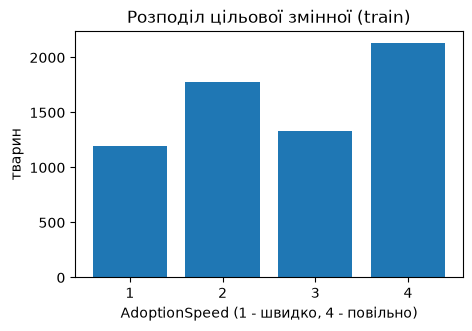

In [4]:
train = pd.read_csv(CSV_DIR / "train.csv", dtype={"PetID": str})
test = pd.read_csv(CSV_DIR / "test.csv", dtype={"PetID": str})
sub = pd.read_csv(CSV_DIR / "sample_submission.csv", dtype={"PetID": str})
print("train:", train.shape, " test:", test.shape, " sample_submission:", sub.shape)
print("NaN train:", train.isna().sum().to_dict())
print("NaN test:", test.isna().sum().to_dict())
display(train.head(3))

target = train.AdoptionSpeed.value_counts().sort_index()
display(pd.DataFrame({"n": target, "частка, %": (100 * target / len(train)).round(1)}))

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(target.index.astype(str), target.values, color="tab:blue")
ax.set_xlabel("AdoptionSpeed (1 - швидко, 4 - повільно)")
ax.set_ylabel("тварин")
ax.set_title("Розподіл цільової змінної (train)")
plt.savefig(FIG_DIR / "eda_target.png", dpi=120, bbox_inches="tight")
plt.show()

Дисбаланс помірний: найбільший клас 4 (33 %), найменший клас 1 (19 %). QWK карає помилку на сусідній клас слабше, ніж на далекий, тому порядок класів має значення і задачу можна розглядати як регресію з порогами.

### Описи

порожніх описів: train 5  test 1
слів в описі (train): {'count': 6431.0, 'mean': 67.4, 'std': 76.1, 'min': 0.0, '25%': 22.0, '50%': 46.0, '75%': 85.0, 'max': 1153.0}


,median,mean,max
AdoptionSpeed,,,
1,49.0,68.5,1153
2,46.0,68.7,870
3,50.5,71.7,936
4,43.0,63.2,789


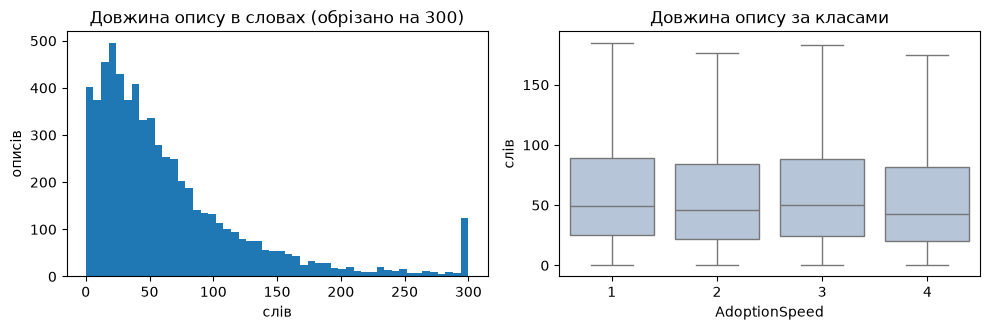

In [5]:
for df in (train, test):
    df["Description"] = df.Description.fillna("")
    df["n_words"] = df.Description.str.split().str.len()

print("порожніх описів: train", int((train.n_words == 0).sum()), " test", int((test.n_words == 0).sum()))
print("слів в описі (train):", train.n_words.describe().round(1).to_dict())
display(train.groupby("AdoptionSpeed").n_words.agg(["median", "mean", "max"]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(train.n_words.clip(upper=300), bins=50, color="tab:blue")
axes[0].set_title("Довжина опису в словах (обрізано на 300)")
axes[0].set_xlabel("слів")
axes[0].set_ylabel("описів")
sns.boxplot(x="AdoptionSpeed", y="n_words", data=train, showfliers=False, color="lightsteelblue", ax=axes[1])
axes[1].set_title("Довжина опису за класами")
axes[1].set_xlabel("AdoptionSpeed")
axes[1].set_ylabel("слів")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_desc_len.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
samples = train[train.n_words > 0].groupby("AdoptionSpeed").sample(2, random_state=SEED)
display(samples[["AdoptionSpeed", "n_words", "Description"]].assign(Description=samples.Description.str.slice(0, 160)))

# частина описів малайською або змішана, перевіряю на кількох частих словах
malay_words = ["manja", "comel", "kucing", "anjing", "sihat", "jantan", "betina", "untuk", "sangat"]
low = train.Description.str.lower()
print("описів зі словом:", {w: int(low.str.contains(rf"\b{w}\b").sum()) for w in malay_words})
any_malay = low.str.contains(r"\b(?:" + "|".join(malay_words) + r")\b")
print(f"хоча б одне з них: {int(any_malay.sum())} ({100 * any_malay.mean():.1f} %)")

# шум у тексті: посилання, китайські ієрогліфи, емодзі, довгі повтори пунктуації
# діапазони через chr(), бо рушій регулярок у pandas з pyarrow не розуміє \u-екранування
patterns = {"посилання": r"https?://|www\.", "ієрогліфи": f"[{chr(0x4E00)}-{chr(0x9FFF)}]",
            "емодзі": f"[{chr(0x1F300)}-{chr(0x1FAFF)}{chr(0x2600)}-{chr(0x27BF)}]", "3+ знаки пунктуації підряд": r"[!?.]{3,}"}
print("описів із шумом:", {k: int(train.Description.str.contains(pat, regex=True).sum()) for k, pat in patterns.items()})

,AdoptionSpeed,n_words,Description
4169,1,67,"I am putting this up for my neighbour, Aunty Aisyah. She's very caring about animals. She helps the strays and feeds them very good food. 4 kittens were bor..."
1671,1,13,"Blue eyes, playful, still milking from mother. Soon will be able to adopt."
3664,2,128,Location: Puchong (Bandar Kinrara) Hi I'm Momo! I'm a highly intelligent kitten that is very attached to people. I love to get myself cosy on people's lap. ...
4298,2,16,cute active healthy puppy for adpotion location balakong jaya..serdang.. tis puppies found at serdang industry park.
4613,3,3,Love my furkids..
2302,3,40,3 male and 1 female puppies for adoption. Their mother was spayed just after it gave birth to these puppies. I have 3 dogs in my house now. I am unable to t...
3122,4,22,Something about Dixie that will keep your heart warm. She likes to play yet an independent cat. Contact on WhatsApp only at.
1883,4,36,"3 puppies looking for home in Subang 2 2 Male, 1 female I can’t keep them as my house already have 2 dogs and my neighbors are complaining. Hope can get the..."


описів зі словом: {'manja': 286, 'comel': 38, 'kucing': 113, 'anjing': 19, 'sihat': 21, 'jantan': 21, 'betina': 14, 'untuk': 66, 'sangat': 58}
хоча б одне з них: 408 (6.3 %)
описів із шумом: {'посилання': 20, 'ієрогліфи': 81, 'емодзі': 110, '3+ знаки пунктуації підряд': 597}


### Фото


фото: train 28472  test 9448
перше фото завжди має номер 1: True
нумерація без пропусків: True


,PetID,photo_no,file
0,000a290e4,1,000a290e4-1.jpg
1,000a290e4,2,000a290e4-2.jpg
2,000fb9572,1,000fb9572-1.jpg


тварин без фото в train: 0
фото на тварину: {'count': 6431.0, 'mean': 4.43, 'std': 3.88, 'min': 1.0, '25%': 2.0, '50%': 4.0, '75%': 5.0, 'max': 30.0}


,mean,median,max
AdoptionSpeed,,,
1,4.18,4.0,30
2,4.73,4.0,30
3,5.38,4.0,30
4,3.72,3.0,30


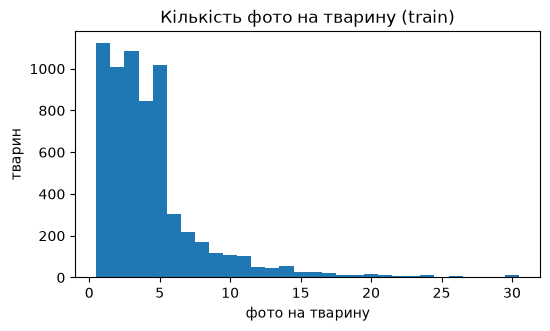

In [7]:
def photo_index(img_dir):
    rows = []
    for p in img_dir.glob("*.jpg"):
        pet_id, no = p.stem.rsplit("-", 1)
        rows.append((pet_id, int(no), p.name))
    return pd.DataFrame(rows, columns=["PetID", "photo_no", "file"]).sort_values(["PetID", "photo_no"]).reset_index(drop=True)


photos_train = photo_index(TRAIN_IMG)
photos_test = photo_index(TEST_IMG)
print("фото: train", len(photos_train), " test", len(photos_test))
print("перше фото завжди має номер 1:", bool((photos_train.groupby("PetID").photo_no.min() == 1).all()))
numbering = photos_train.groupby("PetID").photo_no.agg(["max", "count"])
print("нумерація без пропусків:", bool((numbering["max"] == numbering["count"]).all()))
display(photos_train.head(3))

train["n_photos"] = train.PetID.map(photos_train.groupby("PetID").size()).fillna(0).astype(int)
print("тварин без фото в train:", int((train.n_photos == 0).sum()))
print("фото на тварину:", train.n_photos.describe().round(2).to_dict())
display(train.groupby("AdoptionSpeed").n_photos.agg(["mean", "median", "max"]).round(2))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(train.n_photos, bins=np.arange(0.5, 31.5, 1), color="tab:blue")
ax.set_xlabel("фото на тварину")
ax.set_ylabel("тварин")
ax.set_title("Кількість фото на тварину (train)")
plt.savefig(FIG_DIR / "eda_photos_per_pet.png", dpi=120, bbox_inches="tight")
plt.show()

,w,h,aspect
count,500.00,500.00,500.00
mean,400.79,399.36,1.05
std,125.95,90.83,0.36
min,127.00,194.00,0.43
25%,300.00,300.00,0.75
50%,400.00,400.00,1.00
75%,400.00,480.00,1.33
max,640.00,640.00,1.85


режими: {'RGB': 500}
найчастіші розміри (w, h): {(400, 300): 92, (360, 480): 68, (300, 400): 55, (640, 480): 38, (270, 480): 25}


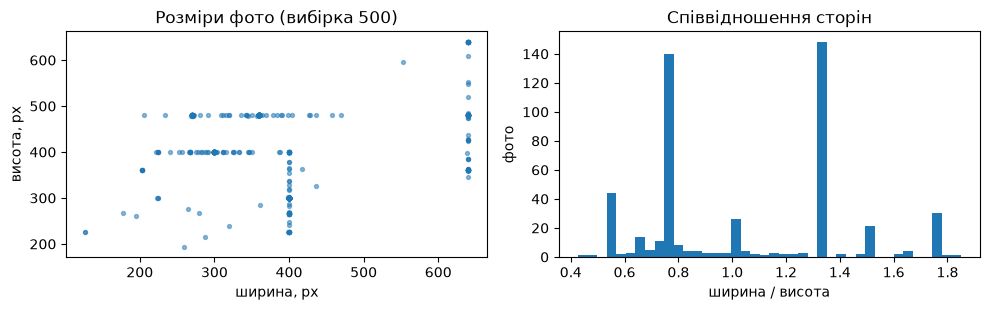

In [8]:
rng = np.random.default_rng(SEED)
sample_files = rng.choice(photos_train.file.tolist(), size=500, replace=False)
rows = []
for f in sample_files:
    # PIL читає лише заголовок, пікселі не декодуються, тому це швидко
    with Image.open(TRAIN_IMG / f) as im:
        rows.append((im.width, im.height, im.mode))
img_sizes = pd.DataFrame(rows, columns=["w", "h", "mode"])
img_sizes["aspect"] = img_sizes.w / img_sizes.h
display(img_sizes[["w", "h", "aspect"]].describe().round(2))
print("режими:", img_sizes["mode"].value_counts().to_dict())
print("найчастіші розміри (w, h):", img_sizes.groupby(["w", "h"]).size().sort_values(ascending=False).head(5).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].scatter(img_sizes.w, img_sizes.h, s=8, alpha=0.5)
axes[0].set_xlabel("ширина, px")
axes[0].set_ylabel("висота, px")
axes[0].set_title("Розміри фото (вибірка 500)")
axes[1].hist(img_sizes.aspect, bins=40, color="tab:blue")
axes[1].set_xlabel("ширина / висота")
axes[1].set_ylabel("фото")
axes[1].set_title("Співвідношення сторін")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_img_sizes.png", dpi=120, bbox_inches="tight")
plt.show()

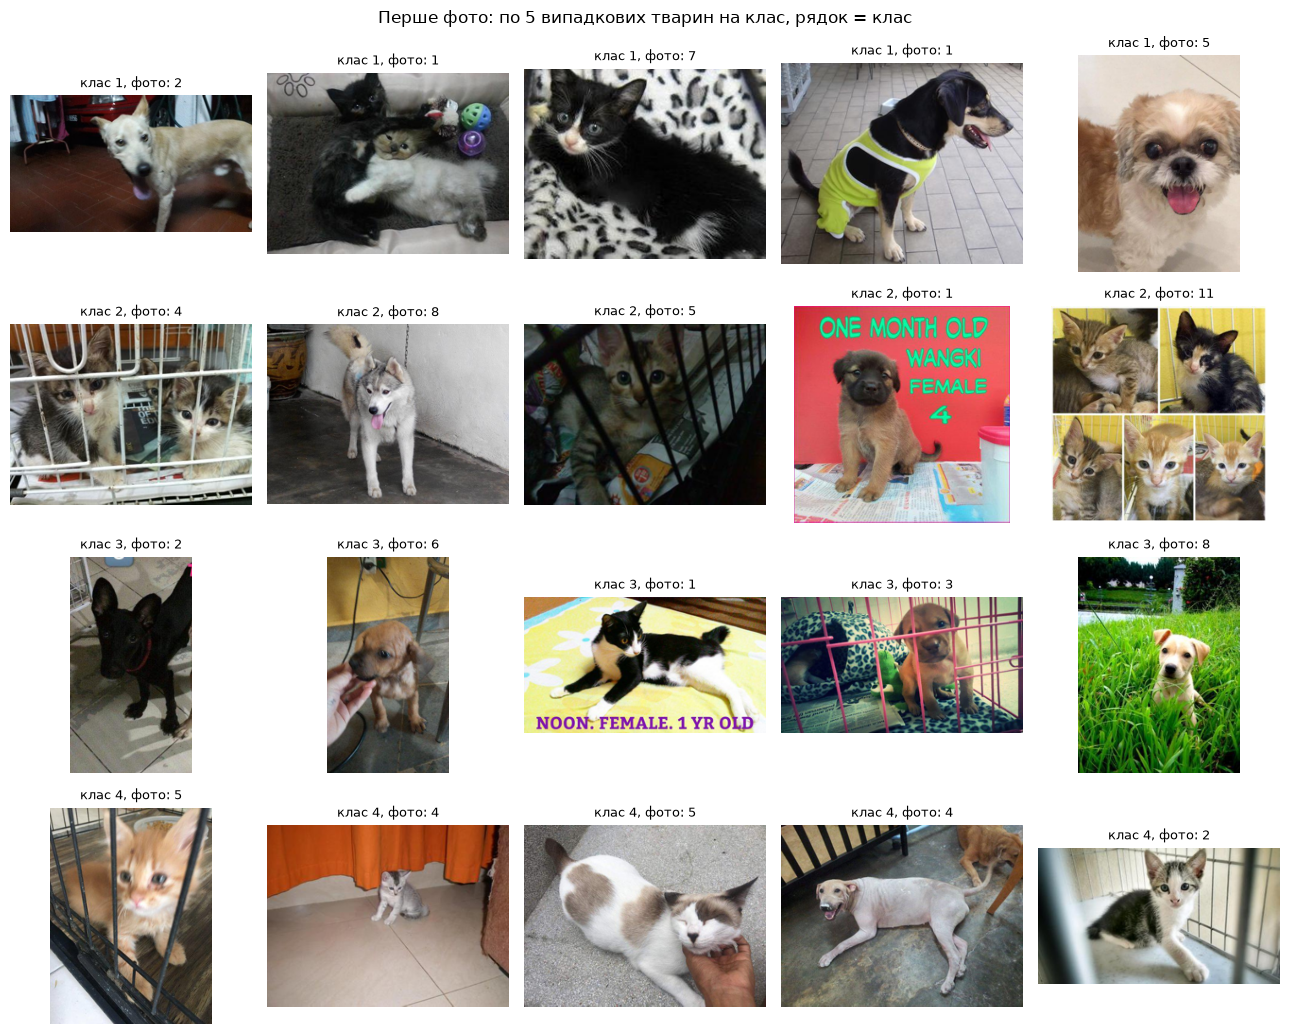

In [9]:
n_photos_by_id = train.set_index("PetID").n_photos

fig, axes = plt.subplots(4, 5, figsize=(13, 10.5))
for row, cls in enumerate([1, 2, 3, 4]):
    ids = train.loc[train.AdoptionSpeed == cls, "PetID"].sample(5, random_state=SEED)
    for ax, pet_id in zip(axes[row], ids):
        with Image.open(TRAIN_IMG / f"{pet_id}-1.jpg") as im:
            im = im.convert("RGB")
            im.thumbnail((256, 256))
            arr = np.asarray(im)
        ax.imshow(arr)
        ax.set_title(f"клас {cls}, фото: {n_photos_by_id[pet_id]}", fontsize=9)
        ax.axis("off")
plt.suptitle("Перше фото: по 5 випадкових тварин на клас, рядок = клас")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_photo_grid.png", dpi=120, bbox_inches="tight")
plt.show()

### Особливість PetID у test

Чотири PetID у test.csv мають 8 символів замість 9: вони складаються лише з цифр, і провідний нуль загубився, коли id зберегли як число. У файлах фото id повний, тому фото шукаю за `PetID.str.zfill(9)`, а в submission лишаю PetID як у test.csv. Ще 8 id фото не мають рядка в test.csv (усі схожі на числа в експоненційному записі, типу 2514503e7), їх просто ігнорую.

In [10]:
print("довжина PetID: train", train.PetID.str.len().value_counts().to_dict(), " test", test.PetID.str.len().value_counts().to_dict())
short_ids = test.loc[test.PetID.str.len() < 9, "PetID"].tolist()
test_photo_ids = set(photos_test.PetID)
for pid in short_ids:
    print(f"{pid}: фото за raw id - {pid in test_photo_ids}, за zfill(9) '{pid.zfill(9)}' - {pid.zfill(9) in test_photo_ids}")

test_ids_z = test.PetID.str.zfill(9)
print("test рядків без фото після zfill:", int((~test_ids_z.isin(test_photo_ids)).sum()))
orphans = sorted(test_photo_ids - set(test_ids_z))
print(f"id фото без рядка в test.csv: {len(orphans)}", orphans)
print("PetID із sample_submission є в test.csv як є:", bool(sub.PetID.isin(test.PetID).all()))

довжина PetID: train {9: 6431}  test {9: 1887, 8: 4}
95314294: фото за raw id - False, за zfill(9) '095314294' - True
35992662: фото за raw id - False, за zfill(9) '035992662' - True
63521459: фото за raw id - False, за zfill(9) '063521459' - True
81301773: фото за raw id - False, за zfill(9) '081301773' - True
test рядків без фото після zfill: 0
id фото без рядка в test.csv: 8 ['02126e289', '2514503e7', '2689341e7', '515462e67', '554965e66', '670535e94', '7759517e2', '867057e77']
PetID із sample_submission є в test.csv як є: True


### Дублікати описів

Один і той самий текст часто повторюється для різних тварин. Перевіряю, чи збігаються мітки всередині таких груп і чи трапляються тексти з train у test.

In [11]:
norm_train = train.Description.str.lower().str.strip()
norm_test = test.Description.str.lower().str.strip()
has_text = norm_train != ""

group_sizes = norm_train[has_text].value_counts()
dup_keys = group_sizes[group_sizes > 1].index
in_dup = has_text & norm_train.isin(dup_keys)
print(f"рядків у групах-дублікатах: {int(in_dup.sum())}, груп: {len(dup_keys)}, найбільша група: {int(group_sizes.max())}")

dup = train.loc[in_dup, ["PetID", "AdoptionSpeed"]].assign(key=norm_train[in_dup])
labels_per_group = dup.groupby("key").AdoptionSpeed.nunique()
print(f"груп з однією міткою: {(labels_per_group == 1).mean():.3f}")


# мітка рядка за більшістю серед його дублікатів, сам рядок із підрахунку виключаю;
# нічию розриваю випадково, інакше порядок value_counts підказував би власну мітку
rng = np.random.default_rng(SEED)


def loo_majority(y):
    preds = []
    for i in y.index:
        c = y.drop(i).value_counts()
        preds.append(rng.choice(c[c == c.max()].index))
    return pd.Series(preds, index=y.index)


dup["pred"] = dup.groupby("key").AdoptionSpeed.transform(loo_majority).astype(int)
acc = (dup.pred == dup.AdoptionSpeed).mean()
kappa = cohen_kappa_score(dup.AdoptionSpeed, dup.pred, weights="quadratic")
base = (dup.AdoptionSpeed == train.AdoptionSpeed.mode()[0]).mean()
print(f"точність за мітками дублікатів: {acc:.3f} (QWK {kappa:.3f}), найчастіший клас на тих самих рядках: {base:.3f}")

for text, n in group_sizes.head(3).items():
    labels = dup.loc[dup.key == text, "AdoptionSpeed"].value_counts().to_dict()
    print(f"n={n}, мітки {labels}: {text[:90]}...")

test_in_train = (norm_test != "") & norm_test.isin(set(norm_train[has_text]))
print(f"описів test, що дослівно є в train: {int(test_in_train.sum())} з {len(test)}")

рядків у групах-дублікатах: 427, груп: 115, найбільша група: 73
груп з однією міткою: 0.687
точність за мітками дублікатів: 0.656 (QWK 0.669), найчастіший клас на тих самих рядках: 0.290
n=73, мітки {3: 29, 2: 28, 1: 14, 4: 2}: for adoption...
n=21, мітки {2: 8, 4: 7, 3: 6}: dog 4 adoption...
n=12, мітки {2: 7, 3: 3, 1: 2}: cat for adoption...
описів test, що дослівно є в train: 133 з 1891


### Дублікати фото

Те саме для фото: однакові файли (збіг md5) у різних оголошень, у тому числі між train і test.

In [12]:
def file_hashes(img_dir, split):
    rows = [(p.name, hashlib.md5(p.read_bytes()).hexdigest()) for p in img_dir.glob("*.jpg")]
    return pd.DataFrame(rows, columns=["file", "md5"]).assign(split=split)


hashes = pd.concat([file_hashes(TRAIN_IMG, "train"), file_hashes(TEST_IMG, "test")], ignore_index=True)
hashes["PetID"] = hashes.file.str.rsplit("-", n=1).str[0]
per_hash = hashes.groupby("md5").agg(pets=("PetID", "nunique"), splits=("split", "nunique"))
shared = per_hash[per_hash.pets > 1]
print(f"унікальних фото: {len(per_hash)}, спільних для кількох тварин: {len(shared)}, з них і в train, і в test: {int((shared.splits == 2).sum())}")

dup_photo = hashes[hashes.md5.isin(shared.index)].drop_duplicates(["md5", "PetID"])
print("тварин зі спільним фото:", dup_photo.groupby("split").PetID.nunique().to_dict())
train_md5 = set(dup_photo.loc[dup_photo.split == "train", "md5"])
print("тварин test, у яких є фото з train:", dup_photo[(dup_photo.split == "test") & dup_photo.md5.isin(train_md5)].PetID.nunique())

labels = train.set_index("PetID").AdoptionSpeed
photo_groups = dup_photo[dup_photo.split == "train"].assign(y=lambda d: d.PetID.map(labels)).groupby("md5").y.agg(["nunique", "count"])
photo_groups = photo_groups[photo_groups["count"] > 1]
print(f"груп train зі спільним фото: {len(photo_groups)}, з однією міткою: {(photo_groups['nunique'] == 1).mean():.3f}")

унікальних фото: 36992, спільних для кількох тварин: 396, з них і в train, і в test: 172
тварин зі спільним фото: {'test': 120, 'train': 317}
тварин test, у яких є фото з train: 95
груп train зі спільним фото: 218, з однією міткою: 0.711


### Train проти test

Міток у test немає, тож порівнюю лише те, що є в обох: довжину опису і кількість фото.

,train,test
"слів, медіана",46.000,49.000
"слів, середнє",67.442,69.315
частка порожніх описів,0.001,0.001
"фото, середнє",4.427,4.959
"фото, медіана",4.000,4.000
"фото, максимум",30.000,30.000


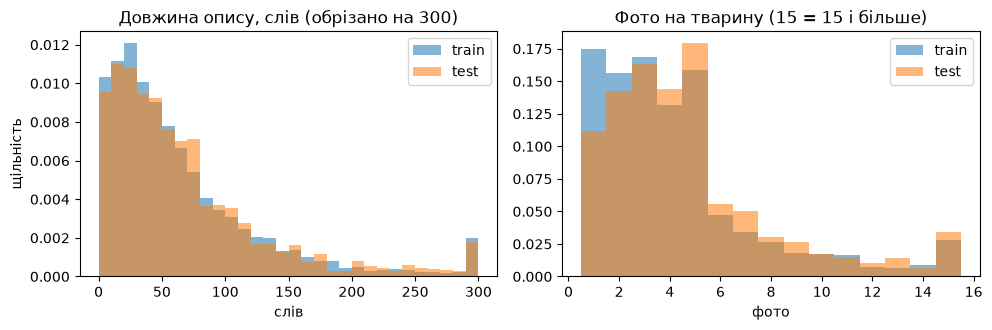

In [13]:
test["n_photos"] = test_ids_z.map(photos_test.groupby("PetID").size()).fillna(0).astype(int)

compare = pd.DataFrame(
    {
        "train": [train.n_words.median(), train.n_words.mean(), (train.n_words == 0).mean(), train.n_photos.mean(), train.n_photos.median(), train.n_photos.max()],
        "test": [test.n_words.median(), test.n_words.mean(), (test.n_words == 0).mean(), test.n_photos.mean(), test.n_photos.median(), test.n_photos.max()],
    },
    index=["слів, медіана", "слів, середнє", "частка порожніх описів", "фото, середнє", "фото, медіана", "фото, максимум"],
).round(3)
display(compare)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for name, df in [("train", train), ("test", test)]:
    axes[0].hist(df.n_words.clip(upper=300), bins=np.arange(0, 310, 10), density=True, alpha=0.55, label=name)
    axes[1].hist(df.n_photos.clip(upper=15), bins=np.arange(0.5, 16.5, 1), density=True, alpha=0.55, label=name)
axes[0].set_title("Довжина опису, слів (обрізано на 300)")
axes[0].set_xlabel("слів")
axes[0].set_ylabel("щільність")
axes[0].legend()
axes[1].set_title("Фото на тварину (15 = 15 і більше)")
axes[1].set_xlabel("фото")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_train_vs_test.png", dpi=120, bbox_inches="tight")
plt.show()

### Висновки для моделювання

Цільова змінна порядкова, а QWK карає далекі помилки сильніше за близькі. Тому природніше вчити регресію або
порядкову модель і підбирати пороги округлення під QWK на валідації. Дисбаланс класів помірний (від 19 до 33 %),
ваги класів окремо перевірю, але великого ефекту не чекаю.

Табличних ознак у датасеті немає, головне джерело інформації - фото. Їх у середньому 4.4 на тварину, тож варто
брати ембеддинги всіх фото й агрегувати по тварині, а не лише перше. Сама кількість фото теж ознака: у класу 4
їх найменше (3.7 у середньому проти 5.4 у класу 3).

Текст другорядний: медіана 46 слів, довжина за класами майже однакова, 5 порожніх описів. Шуму мало (посилання у 20
описах, ієрогліфи у 81, емодзі у 110), тому текст піде в токенізатори без чистки. Беру ембеддинги опису, прості
статистики тексту навряд чи щось дадуть.

Повторювані описи - це серії оголошень, з однаковою міткою приблизно у 69 % груп. Мітка за більшістю дублікатів
вгадує клас у 66 % випадків проти 29 % для найчастішого класу, хоча найбільші групи - це короткі
шаблонні тексти типу "for adoption" з мішаними мітками, а однакові мітки частіше в малих групах з довшим текстом.
Те саме з фото: 396 файлів повторюються в різних оголошень, у 71 % таких груп train мітка одна, а 95 тварин test
мають фото, яке є в train. Тому дублікати лишаю, а мітки найближчих сусідів у train (за текстом і за фото) стануть
сильною ознакою. 133 тексти з test є в train дослівно.

Фото шукаю за PetID.str.zfill(9), у submission PetID лишаю як у test.csv. Розподіли train і test за довжиною
тексту і кількістю фото близькі (у test трохи більше фото, 5.0 проти 4.4 у середньому, медіани однакові), тож
за цими ознаками зсуву між train і test не видно.

## 2. Ембеддинги фото і описів

Усі фото і описи переводжу у вектори заморожених енкодерів, далі моделі вчаться вже на векторах.
Фото: CLIP ViT-L/14 і SigLIP2 so400m. Текст: текстова вежа CLIP і bge-base. Вектори зберігаю в `Results/embeddings`.
На Apple M4 Pro найдовший крок, SigLIP2 по 38 тисячах фото, іде близько пів години.

### Індекс фото

Для пошуку фото id доповнюю нулем зліва до 9 символів (особливість PetID з розділу 1), фото без рядка в csv
відпадають. Таблиці pets і photos зберігаю поруч з векторами, далі всі масиви йдуть у порядку рядків pets.

In [14]:
pets = pd.concat([train[["PetID", "Description", "AdoptionSpeed"]].assign(split="train"),
                  test[["PetID", "Description"]].assign(split="test")], ignore_index=True)
pets["img_id"] = pets.PetID.str.zfill(9)

rows = []
for split, d in IMG_DIRS.items():
    for p in sorted(d.glob("*.jpg")):
        img_id, no = p.stem.rsplit("-", 1)
        rows.append((img_id, int(no), str(p)))
photos = pd.DataFrame(rows, columns=["img_id", "photo_no", "path"])
photos = photos.merge(pets[["img_id", "PetID", "split"]], on="img_id")   # inner join: фото без рядка в csv відпадають
photos = photos.sort_values(["split", "img_id", "photo_no"]).reset_index(drop=True)

pets["n_img"] = pets.PetID.map(photos.groupby("PetID").size()).fillna(0).astype(int)
print(photos.split.value_counts().to_dict())
print("тварин:", len(pets), " без фото:", (pets.n_img == 0).sum())

pets.to_csv(EMB_DIR / "pets.csv", index=False)
photos.to_csv(EMB_DIR / "photos.csv", index=False)

{'train': 28472, 'test': 9377}
тварин: 8322  без фото: 0


### Енкодери зображень

Дві контрастивні моделі: `openai/clip-vit-large-patch14` (768 чисел на фото) і `google/siglip2-so400m-patch14-224`
(1152). Їх учили на сотнях мільйонів пар фото-текст, тому простір ознак уже розрізняє вид, породу, вік, стан
тварини і якість знімка. Ваги не чіпаю, тільки прямий прохід у fp16. Кожне фото кодую окремо, агрегація по тварині далі.

In [15]:
class PhotoDataset(Dataset):
    def __init__(self, paths, processor):
        self.paths = paths
        self.processor = processor

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.processor(images=img, return_tensors="pt")["pixel_values"][0]


BATCH_SIZE = 64


def projected(out):
    # transformers 5 повертає обгортку з проєкцією в pooler_output, 4.x одразу тензор
    return out.pooler_output if hasattr(out, "pooler_output") else out


@torch.no_grad()
def encode_images(model_name, paths):
    processor = AutoProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, dtype=dtype).to(device).eval()
    loader = DataLoader(PhotoDataset(paths, processor), batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    out = []
    for px in tqdm(loader, desc=model_name.split("/")[-1], mininterval=30):
        feats = projected(model.get_image_features(pixel_values=px.to(device, dtype)))
        out.append(feats.float().cpu())
    del model
    free_memory()
    return torch.cat(out).numpy().astype(np.float16)

In [16]:
IMAGE_ENCODERS = {"clip": "openai/clip-vit-large-patch14", "siglip2": "google/siglip2-so400m-patch14-224"}

for key, name in IMAGE_ENCODERS.items():
    f = EMB_DIR / f"photo_{key}.npy"
    if f.exists():
        cached = np.load(f, mmap_mode="r")
        assert cached.shape[0] == len(photos), "кеш не збігається з індексом фото, видали файл і перерахуй"
        print(f.name, "вже є", cached.shape)
        continue
    t0 = time.time()
    vectors = encode_images(name, photos.path.tolist())
    np.save(f, vectors)
    print(f.name, vectors.shape, f"{(time.time() - t0) / 60:.1f} хв")

photo_clip.npy (37849, 768) 23.4 хв


photo_siglip2.npy (37849, 1152) 31.8 хв


### Енкодери тексту

Текстова вежа CLIP дає вектор у тому ж просторі, що й фото, але бачить лише перші 77 токенів.
Другий енкодер, `BAAI/bge-base-en-v1.5`, учили саме на подібність речень, він читає до 512 токенів, цього вистачає
майже на всі описи. Беру вектор токена [CLS], як радять автори моделі. Порожній опис кодую як є, це теж інформація.
Текст іде в токенізатори без чистки: регістр і пунктуацію вони обробляють самі, посилань та ієрогліфів у даних
менше 2 %, а чистка лише прибрала б інформацію. Обидві моделі англомовні, малайські вставки (близько 6 % описів)
вони бачать як незнайомі слова, це свідома втрата заради простоти.

In [17]:
@torch.no_grad()
def encode_texts(model_name, texts, max_length, pooling):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, dtype=dtype).to(device).eval()
    out = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=model_name.split("/")[-1], mininterval=30):
        batch = tokenizer(texts[i:i + BATCH_SIZE], padding=True, truncation=True, max_length=max_length,
                          return_tensors="pt").to(device)
        if pooling == "clip":
            feats = projected(model.get_text_features(**batch))
        else:
            feats = model(**batch).last_hidden_state[:, 0]
        out.append(feats.float().cpu())
    del model
    free_memory()
    return torch.cat(out).numpy().astype(np.float16)


TEXT_ENCODERS = {"clip": ("openai/clip-vit-large-patch14", 77, "clip"), "bge": ("BAAI/bge-base-en-v1.5", 512, "cls")}
texts = pets.Description.tolist()

for key, (name, max_len, pooling) in TEXT_ENCODERS.items():
    f = EMB_DIR / f"text_{key}.npy"
    if f.exists():
        cached = np.load(f, mmap_mode="r")
        assert cached.shape[0] == len(pets), "кеш не збігається з таблицею тварин, видали файл і перерахуй"
        print(f.name, "вже є", cached.shape)
        continue
    t0 = time.time()
    vectors = encode_texts(name, texts, max_len, pooling)
    np.save(f, vectors)
    print(f.name, vectors.shape, f"{time.time() - t0:.0f} с")

text_clip.npy (8322, 768) 29 с


text_bge.npy (8322, 768) 154 с


### Агрегація по тварині

Вектор кожного фото нормалізую до одиничної довжини, усереднюю по тварині і середнє знову нормалізую. Так тварина
з 20 фото і тварина з одним живуть в одному масштабі, а косинус між тваринами має сенс.

In [18]:
def pool_by_pet(emb):
    e = F.normalize(torch.from_numpy(emb.astype(np.float32)), dim=-1).numpy()
    pos = {pid: i for i, pid in enumerate(pets.PetID)}
    mean = np.zeros((len(pets), e.shape[1]), np.float32)
    first = np.zeros_like(mean)
    for pid, idx in photos.groupby("PetID", sort=False).indices.items():
        v = e[idx].mean(0)
        mean[pos[pid]] = v / np.linalg.norm(v)
        first[pos[pid]] = e[idx[0]]          # photos відсортовано за photo_no, idx[0] це фото номер 1
    return mean.astype(np.float16), first.astype(np.float16)


for key in IMAGE_ENCODERS:
    mean, first = pool_by_pet(np.load(EMB_DIR / f"photo_{key}.npy"))
    np.save(EMB_DIR / f"pet_{key}_mean.npy", mean)
    np.save(EMB_DIR / f"pet_{key}_first.npy", first)
    print(key, mean.shape, "нульових рядків:", int((np.abs(mean).sum(1) == 0).sum()))

for f in sorted(EMB_DIR.iterdir()):
    print(f"{f.name:28s} {f.stat().st_size / 2**20:7.1f} MB")

clip (8322, 768) нульових рядків: 0


siglip2 (8322, 1152) нульових рядків: 0
pet_clip_first.npy              12.2 MB
pet_clip_mean.npy               12.2 MB
pet_siglip2_first.npy           18.3 MB
pet_siglip2_mean.npy            18.3 MB
pets.csv                         3.2 MB
photo_clip.npy                  55.4 MB
photo_siglip2.npy               83.2 MB
photos.csv                       2.5 MB
text_bge.npy                    12.2 MB
text_clip.npy                   12.2 MB


### Перевірка, що вектори осмислені

Спочатку що саме процесори роблять з фото і яку частку описів обрізають токенізатори. CLIP зменшує коротшу
сторону до 224 і бере центральний квадрат, SigLIP2 стискає все фото в 224x224 без кропу, нормалізація у кожного
своя. Для фото 4:3 з розділу 1 це означає, що CLIP втрачає краї кадру, а SigLIP2 трохи спотворює пропорції, обидва
енкодери так і навчалися. Текстовий CLIP обрізає близько 40 % описів на 77 токенах, bge майже нічого.
Далі тести: фото однієї тварини мають бути ближчими одне до одного, ніж випадкові, однакові описи мають давати
однакові вектори (це перевіряє, що рядки не переплутані), zero-shot запит "кіт чи собака" має давати
правдоподібний поділ, а найближчі сусіди тестової тварини мають виглядати схоже.

In [19]:
def compact(size):
    d = size if isinstance(size, dict) else vars(size)
    return {k: v for k, v in d.items() if v is not None}


for key, name in IMAGE_ENCODERS.items():
    ip = AutoProcessor.from_pretrained(name).image_processor
    crop = compact(ip.crop_size) if getattr(ip, "do_center_crop", False) else "без кропу"
    print(f"{key:8s} resize: {compact(ip.size)}  crop: {crop}  mean: {np.round(ip.image_mean, 3).tolist()}")
for key, (name, max_len, _) in TEXT_ENCODERS.items():
    lens = np.array([len(ids) for ids in AutoTokenizer.from_pretrained(name)(texts, truncation=False)["input_ids"]])
    print(f"text {key:5s} описів довших за {max_len} токенів: {(lens > max_len).mean():.1%}")


def load_unit(name):
    return F.normalize(torch.from_numpy(np.load(EMB_DIR / f"{name}.npy").astype(np.float32)), dim=-1)


groups = [idx for idx in photos.groupby("PetID", sort=False).indices.values() if len(idx) > 1]
a = torch.tensor([g[0] for g in groups])
b = torch.tensor([g[1] for g in groups])
gen = torch.Generator().manual_seed(SEED)       # свій генератор, щоб пари не залежали від клітинок вище
rnd = torch.randperm(len(photos), generator=gen)[: len(a)]
for key in IMAGE_ENCODERS:
    e = load_unit(f"photo_{key}")
    print(f"{key:8s} cos двох фото однієї тварини: {(e[a] * e[b]).sum(1).mean():.3f}, випадкових фото: {(e[a] * e[rnd]).sum(1).mean():.3f}")

norm_desc = pets.Description.str.lower().str.strip()
dup_idx = pets.index[(norm_desc != "") & norm_desc.duplicated(keep=False)]
pairs = pd.Series(dup_idx, index=norm_desc[dup_idx]).groupby(level=0).agg(lambda s: (s.iloc[0], s.iloc[1]))
ta = torch.tensor([p[0] for p in pairs])
tb = torch.tensor([p[1] for p in pairs])
rnd = torch.randperm(len(pets), generator=gen)[: len(ta)]
for key in TEXT_ENCODERS:
    e = load_unit(f"text_{key}")
    print(f"text {key:5s} cos однакових описів: {(e[ta] * e[tb]).sum(1).mean():.3f}, випадкових: {(e[ta] * e[rnd]).sum(1).mean():.3f}")

pet_clip = load_unit("pet_clip_mean")
tokenizer = AutoTokenizer.from_pretrained(IMAGE_ENCODERS["clip"])
clip = AutoModel.from_pretrained(IMAGE_ENCODERS["clip"]).eval()
with torch.no_grad():
    prompts = projected(clip.get_text_features(**tokenizer(["a photo of a cat", "a photo of a dog"], padding=True, return_tensors="pt")))
pets["species_zs"] = np.where((pet_clip @ F.normalize(prompts, dim=-1).T).argmax(1).numpy() == 0, "cat", "dog")
print(pets.groupby(["split", "species_zs"]).size().unstack())
print("середня швидкість адопції за zero-shot видом:")
print(pets[pets.split == "train"].groupby("species_zs").AdoptionSpeed.mean().round(2))
del clip

clip     resize: {'shortest_edge': 224}  crop: {'height': 224, 'width': 224}  mean: [0.481, 0.458, 0.408]


siglip2  resize: {'height': 224, 'width': 224}  crop: без кропу  mean: [0.5, 0.5, 0.5]


text clip  описів довших за 77 токенів: 39.4%


text bge   описів довших за 512 токенів: 1.0%
clip     cos двох фото однієї тварини: 0.860, випадкових фото: 0.705
siglip2  cos двох фото однієї тварини: 0.870, випадкових фото: 0.670
text clip  cos однакових описів: 1.000, випадкових: 0.501
text bge   cos однакових описів: 1.000, випадкових: 0.608


species_zs   cat   dog
split                 
test         813  1078
train       2793  3638
середня швидкість адопції за zero-shot видом:
species_zs
cat    2.50
dog    2.83
Name: AdoptionSpeed, dtype: float64


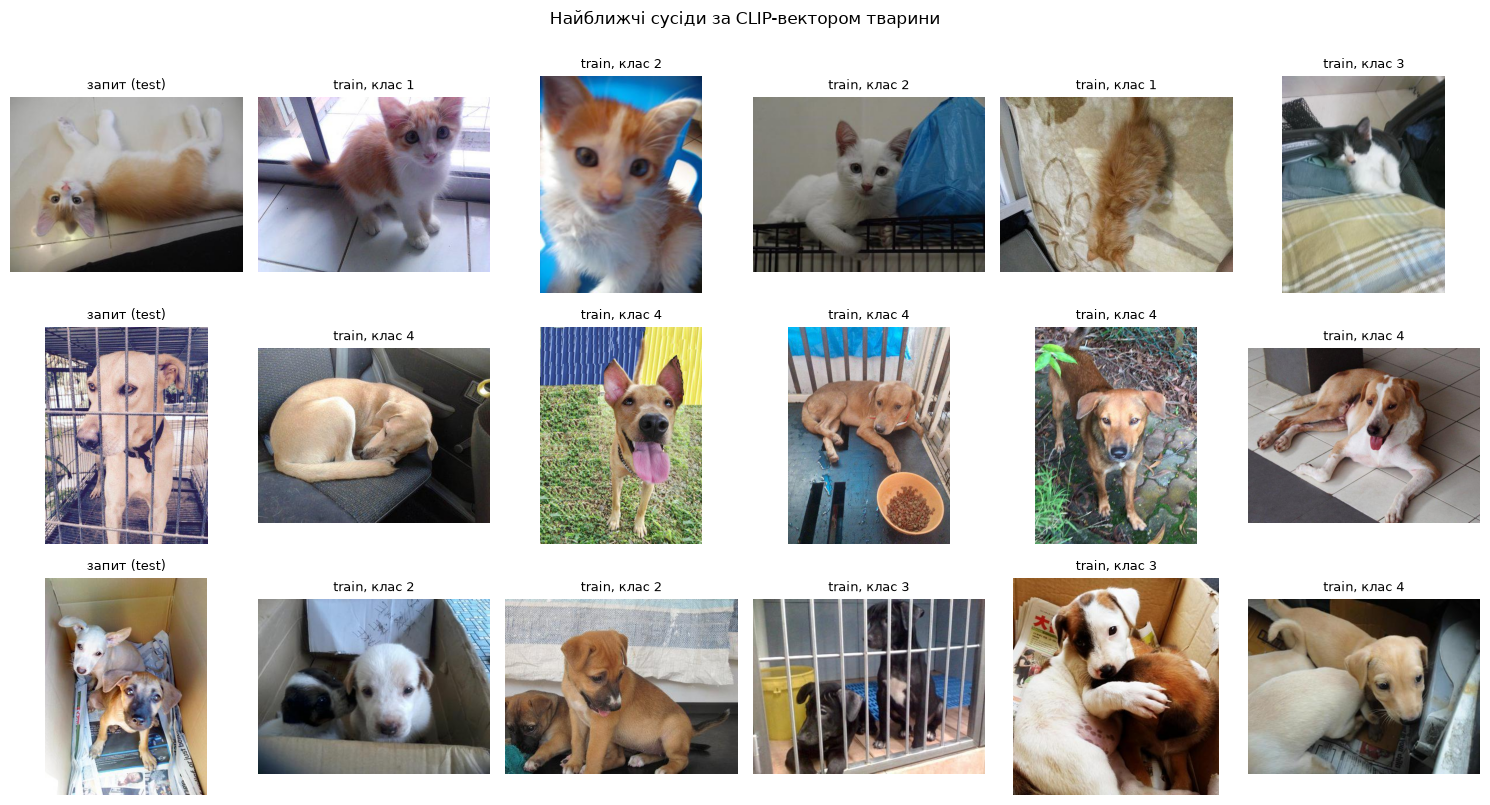

In [20]:
first_photo = photos.drop_duplicates("PetID").set_index("PetID").path
train_idx = np.flatnonzero(pets.split == "train")
rng = np.random.default_rng(SEED)
queries = rng.choice(np.flatnonzero(pets.split == "test"), 3, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row, q in zip(axes, queries):
    sims = pet_clip[train_idx] @ pet_clip[q]
    top = train_idx[sims.topk(5).indices.numpy()]
    for ax, i in zip(row, [q, *top]):
        ax.imshow(Image.open(first_photo[pets.PetID[i]]))
        ax.axis("off")
        ax.set_title("запит (test)" if i == q else f"train, клас {pets.AdoptionSpeed[i]:.0f}", fontsize=9)
plt.suptitle("Найближчі сусіди за CLIP-вектором тварини", y=1.0)
plt.tight_layout()
plt.savefig(FIG_DIR / "emb_neighbors.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Моделі на ембеддингах і сабмішен

Схема: лінійні моделі на ембеддингах як базова лінія, далі ознаки з міток сусідів, кілька моделей першого рівня і
бустинг другого рівня поверх усього. Наприкінці фінальні моделі перенавчаю на всьому train і пишу сабмішен.

In [21]:
is_train = (pets.split == "train").values
tr_idx, te_idx = np.flatnonzero(is_train), np.flatnonzero(~is_train)
y = pets.AdoptionSpeed.values[tr_idx].astype(int)


def load_emb(name):
    e = np.load(EMB_DIR / f"{name}.npy").astype(np.float32)
    return e / np.clip(np.linalg.norm(e, axis=1, keepdims=True), 1e-6, None)


emb = {k: load_emb(k) for k in ["pet_clip_mean", "pet_clip_first", "pet_siglip2_mean", "text_clip", "text_bge"]}
for k, v in emb.items():
    print(f"{k:18s} {v.shape}")
print("train:", len(tr_idx), " test:", len(te_idx), " класи:", np.bincount(y)[1:])

pet_clip_mean      (8322, 768)
pet_clip_first     (8322, 768)
pet_siglip2_mean   (8322, 1152)
text_clip          (8322, 768)
text_bge           (8322, 768)
train: 6431  test: 1891  класи: [1197 1773 1328 2133]


### Метрика і пороги

QWK карає квадратом відстані між класами: сплутати 1 і 4 у дев'ять разів гірше, ніж 1 і 2. Тому зручно
передбачати число, а класи різати порогами. Пороги підбираю методом Nelder-Mead прямо під QWK, стартуючи з
квантилів, які відтворюють частоти класів train. Щоб оцінка в крос-валідації не була завищеною, пороги для
кожного фолду беру з OOF-прогнозів решти фолдів.

In [22]:
def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


def apply_thresholds(pred, thr):
    return 1 + np.searchsorted(np.sort(thr), pred)


def fit_thresholds(pred, y_true):
    cum = np.cumsum(np.bincount(y_true, minlength=5)[1:4]) / len(y_true)
    init = np.quantile(pred, cum)
    loss = lambda thr: -qwk(y_true, apply_thresholds(pred, thr))
    return np.sort(minimize(loss, init, method="Nelder-Mead", options={"xatol": 1e-4, "maxiter": 400}).x)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(tr_idx, y))      # позиції в межах train, одні й ті самі для всіх моделей


def cv_qwk(oof, y_true=y):
    pred = np.zeros(len(y_true), int)
    for tr, va in folds:
        pred[va] = apply_thresholds(oof[va], fit_thresholds(oof[tr], y_true[tr]))
    return qwk(y_true, pred), pred


results = {}


def report(name, oof):
    score, pred = cv_qwk(oof)
    fold_std = np.std([qwk(y[va], pred[va]) for _, va in folds])    # розкид між фолдами, щоб бачити, що є шумом
    results[name] = (score, fold_std)
    print(f"{name:48s} QWK = {score:.4f}  (std по фолдах {fold_std:.3f})")


def cv_predict(make_model, X, proba=False):
    # OOF-прогноз для train і прогноз для test моделлю, навченою на всьому train
    X_tr, X_te = X[tr_idx], X[te_idx]
    oof = np.zeros((len(tr_idx), 4) if proba else len(tr_idx))
    for tr, va in folds:
        model = make_model().fit(X_tr[tr], y[tr])
        oof[va] = model.predict_proba(X_tr[va]) if proba else model.predict(X_tr[va])
    model = make_model().fit(X_tr, y)
    test = model.predict_proba(X_te) if proba else model.predict(X_te)
    return oof, test

### Базові моделі

Ridge на кожному наборі ознак окремо. Це відповідь на питання, де сигнал: у метаданих, тексті чи фото, у першому
фото чи в усіх, у CLIP чи в SigLIP2. RidgeCV сам обирає силу регуляризації, лише для розрідженої матриці TF-IDF
на 35 тисяч стовпців alpha фіксую. Константний прогноз дає QWK = 0 за означенням, тому перша реальна лінія -
кількість фото і довжина опису.

In [23]:
n_words = pets.Description.str.split().str.len().values
meta_X = np.c_[pets.n_img.values, np.log1p(pets.n_img.values), n_words, np.log1p(n_words)].astype(np.float32)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50_000, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(pets.Description)
print("TF-IDF:", X_tfidf.shape)

ridge_cv = lambda: RidgeCV(alphas=np.logspace(-1, 4, 11))
feature_sets = {
    "meta": ("мета: кількість фото, довжина опису", meta_X),
    "tfidf": ("текст: TF-IDF", X_tfidf),
    "text_clip": ("текст: CLIP text", emb["text_clip"]),
    "text_bge": ("текст: bge", emb["text_bge"]),
    "clip_first": ("фото: CLIP, тільки перше фото", emb["pet_clip_first"]),
    "clip": ("фото: CLIP, середнє по всіх фото", emb["pet_clip_mean"]),
    "siglip2": ("фото: SigLIP2, середнє по всіх фото", emb["pet_siglip2_mean"]),
    "img": ("фото: CLIP + SigLIP2", np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"]])),
    "all": ("фото + текст: усі ембеддинги", np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"], emb["text_clip"], emb["text_bge"]])),
}
ridge_preds = {}      # OOF і test прогнози кожної базової лінії, далі вони стануть ознаками другого рівня
for key, (label, X) in feature_sets.items():
    make = (lambda: Ridge(alpha=3.0)) if key == "tfidf" else ridge_cv    # RidgeCV на розрідженій матриці повільний
    ridge_preds[key] = cv_predict(make, X)
    report(f"Ridge, {label}", ridge_preds[key][0])

TF-IDF: (8322, 34662)


Ridge, мета: кількість фото, довжина опису       QWK = 0.0915  (std по фолдах 0.030)


Ridge, текст: TF-IDF                             QWK = 0.3437  (std по фолдах 0.007)


Ridge, текст: CLIP text                          QWK = 0.3410  (std по фолдах 0.027)


Ridge, текст: bge                                QWK = 0.2965  (std по фолдах 0.019)


Ridge, фото: CLIP, тільки перше фото             QWK = 0.5623  (std по фолдах 0.019)


Ridge, фото: CLIP, середнє по всіх фото          QWK = 0.5869  (std по фолдах 0.016)


Ridge, фото: SigLIP2, середнє по всіх фото       QWK = 0.5921  (std по фолдах 0.013)


Ridge, фото: CLIP + SigLIP2                      QWK = 0.5910  (std по фолдах 0.012)


Ridge, фото + текст: усі ембеддинги              QWK = 0.5964  (std по фолдах 0.018)


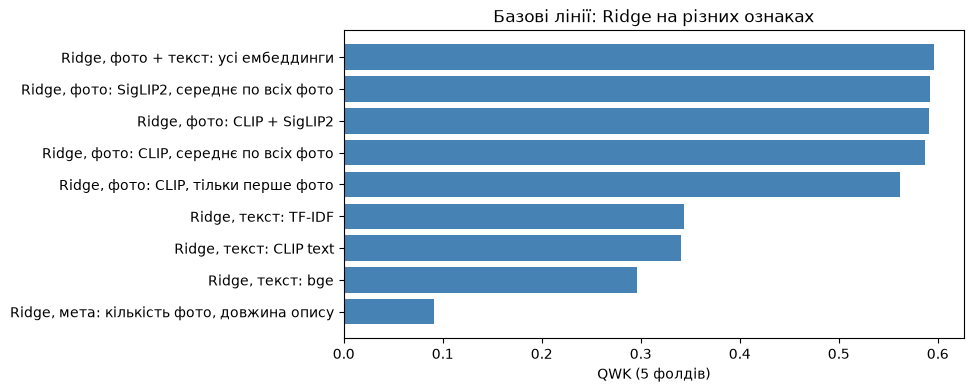

In [24]:
base = pd.Series({k: v[0] for k, v in results.items()}).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(base.index, base.values, color="steelblue")
plt.xlabel("QWK (5 фолдів)")
plt.title("Базові лінії: Ridge на різних ознаках")
plt.savefig(FIG_DIR / "models_baselines.png", dpi=120, bbox_inches="tight")
plt.show()

### Ознаки з міток сусідів

Однакові або схожі оголошення (один притулок, та сама серія фото) часто мають однакову швидкість адопції.
Для кожної тварини шукаю 20 найближчих за косинусом тварин з train і беру статистики їхніх міток: середню по
топ-5 і топ-20, зважену softmax-вагами, мітку і схожість найближчого, частки класів серед сусідів.
Щоб не підглядати у власну мітку, для рядків train сусідів шукаю серед решти train (leave-one-out), а всередині
крос-валідації тільки серед навчальної частини фолду. Окремо рахую дублікати опису слово в слово.

In [25]:
K = 20


def unit(a):
    return a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-6, None)


spaces = {
    "img": unit(np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"]])),
    "txt": emb["text_bge"],
    "all": unit(np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"], emb["text_clip"], emb["text_bge"]])),
}
spaces = {k: torch.tensor(v, device=device) for k, v in spaces.items()}
labels_all = torch.tensor(np.nan_to_num(pets.AdoptionSpeed.values), device=device, dtype=torch.float32)
desc_key = pets.Description.str.lower().str.replace(r"\s+", " ", regex=True).str.strip().values


def knn_block(E, q_idx, ref_idx, exclude_self):
    S = E[q_idx] @ E[ref_idx].T
    if exclude_self:
        S.fill_diagonal_(-2.0)                       # q_idx == ref_idx, себе не рахую
    sim, pos = S.topk(K, dim=1)
    lab = labels_all[torch.as_tensor(ref_idx, device=device)[pos]]
    w = torch.softmax(sim / 0.05, dim=1)
    feats = [lab[:, :5].mean(1), lab.mean(1), (w * lab).sum(1), lab[:, 0], sim[:, 0], sim[:, :5].mean(1)]
    feats += [(lab == c).float().mean(1) for c in range(1, 5)]
    return torch.stack(feats, 1).cpu().numpy()


def dup_block(q_idx, ref_idx, exclude_self):
    ref = pd.DataFrame({"key": desc_key[ref_idx], "y": pets.AdoptionSpeed.values[ref_idx]})
    g = ref[ref.key != ""].groupby("key").y.agg(["sum", "count"])
    s = np.nan_to_num(g["sum"].reindex(desc_key[q_idx]).values)
    c = np.nan_to_num(g["count"].reindex(desc_key[q_idx]).values)
    if exclude_self:
        own = desc_key[q_idx] != ""
        s, c = s - own * pets.AdoptionSpeed.values[q_idx], c - own
    mean = np.where(c > 0, s / np.maximum(c, 1), np.nan)
    return np.c_[c, mean]


def knn_features(q_idx, ref_idx, exclude_self=False):
    if exclude_self:
        assert np.array_equal(q_idx, ref_idx)
    blocks = [knn_block(E, q_idx, ref_idx, exclude_self) for E in spaces.values()]
    return np.hstack(blocks + [dup_block(q_idx, ref_idx, exclude_self)])


stat_names = ["mean5", "mean20", "wmean", "nn_label", "nn_sim", "sim5", "p1", "p2", "p3", "p4"]
knn_names = [f"knn_{s}_{f}" for s in spaces for f in stat_names] + ["dup_count", "dup_mean"]

knn_loo = pd.DataFrame(knn_features(tr_idx, tr_idx, exclude_self=True), columns=knn_names)
corr = knn_loo.apply(lambda col: spearmanr(col, y, nan_policy="omit").correlation)
print("кореляція Спірмена з AdoptionSpeed:")
print(corr.sort_values(key=np.abs, ascending=False).round(3).head(12).to_string())
print(f"\nрядків з дублікатом опису в train: {(knn_loo.dup_count > 0).sum()}")
report("kNN: зважена середня мітка сусідів (фото + текст)", knn_loo.knn_all_wmean.values)
report("kNN: зважена середня мітка сусідів (тільки фото)", knn_loo.knn_img_wmean.values)

кореляція Спірмена з AdoptionSpeed:
dup_mean            0.706
knn_img_wmean       0.567
knn_img_mean20      0.555
knn_all_wmean       0.545
knn_img_p4          0.528
knn_img_mean5       0.526
knn_all_mean20      0.515
knn_all_mean5       0.475
knn_all_p4          0.466
knn_img_p1         -0.453
knn_all_p1         -0.392
knn_img_nn_label    0.390

рядків з дублікатом опису в train: 427


kNN: зважена середня мітка сусідів (фото + текст) QWK = 0.5174  (std по фолдах 0.012)


kNN: зважена середня мітка сусідів (тільки фото) QWK = 0.5435  (std по фолдах 0.016)


### Моделі першого рівня

Ridge з базових ліній уже дав по одному прогнозу на кожен набір ознак, усі вони підуть на другий рівень: так
бустинг сам зважить, скільки вірити фото, а скільки тексту. Сюди додаю моделі на повному стандартизованому
векторі ембеддингів (CLIP + SigLIP2 + два текстові): SVR дає число, логістична регресія і MLP дають імовірності
класів. OOF-прогнози стають ознаками другого рівня, прогнози для test роблять моделі, перенавчені на всьому train.

In [26]:
X_all = np.hstack([emb["pet_clip_mean"], emb["pet_siglip2_mean"], emb["text_clip"], emb["text_bge"]])
X_std = StandardScaler().fit_transform(X_all).astype(np.float32)
print(X_std.shape)

level1 = {}
for name, make, proba in [
    ("svr", lambda: SVR(C=1.0, epsilon=0.2), False),
    ("logreg", lambda: LogisticRegression(C=0.005, max_iter=1000), True),
]:
    t0 = time.time()
    level1[name] = cv_predict(make, X_std, proba=proba)
    oof = level1[name][0] @ np.arange(1, 5) if proba else level1[name][0]
    report(f"L1 {name}", oof)
    print(f"{'':48s} {time.time() - t0:.0f} с")

(8322, 3456)


L1 svr                                           QWK = 0.6093  (std по фолдах 0.016)
                                                 114 с


L1 logreg                                        QWK = 0.5571  (std по фолдах 0.015)
                                                 4 с


### MLP з L2-регуляризацією у функції втрат

MLP пишу сам: два шари, dropout, L2-штраф на ваги, доданий прямо у функцію втрат, і label smoothing. Кількість
епох фіксована, без ранньої зупинки на валідаційному фолді, інакше OOF-прогноз був би оптимістичним.

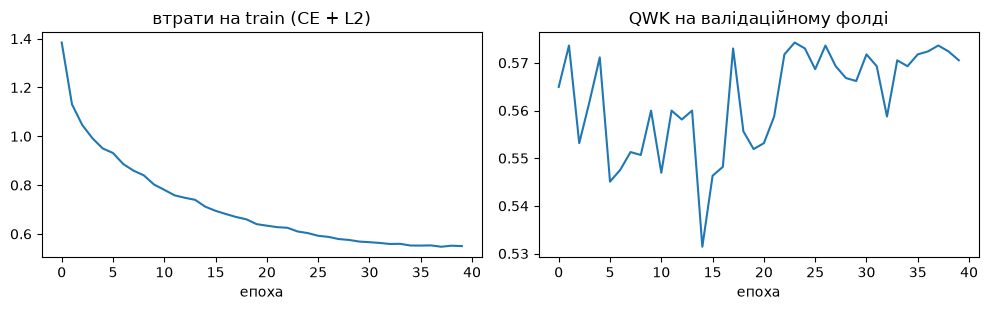

In [27]:
class MLP(nn.Module):
    def __init__(self, d_in, d_hidden=512, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.2), nn.Linear(d_in, d_hidden), nn.GELU(),
            nn.Dropout(0.5), nn.Linear(d_hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def mlp_loss(model, logits, target, l2=3e-4):
    penalty = sum(p.pow(2).sum() for p in model.parameters() if p.ndim == 2)
    return F.cross_entropy(logits, target, label_smoothing=0.1) + l2 * penalty


def fit_mlp(X_tr, y_tr, X_ev, epochs=25, lr=1e-3, batch_size=128, eval_each_epoch=None):
    torch.manual_seed(SEED)
    model = MLP(X_tr.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xt, yt = torch.tensor(X_tr, device=device), torch.tensor(y_tr - 1, device=device)
    Xe = torch.tensor(X_ev, device=device)
    cum_train = np.cumsum(np.bincount(y_tr, minlength=5)[1:4]) / len(y_tr)   # для кривої пороги за частотами train, без міток валідації
    history = []
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(Xt), device=device)
        total = 0.0
        for i in range(0, len(Xt), batch_size):
            b = perm[i:i + batch_size]
            loss = mlp_loss(model, model(Xt[b]), yt[b])
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(b)
        sched.step()
        if eval_each_epoch is not None:
            model.eval()
            with torch.no_grad():
                ev = torch.softmax(model(Xe), 1).cpu().numpy() @ np.arange(1, 5)
            history.append((total / len(Xt), qwk(eval_each_epoch, apply_thresholds(ev, np.quantile(ev, cum_train)))))
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(Xe), 1).cpu().numpy()
    return probs, history


# крива навчання на фолді 0, за нею обрано epochs=25 для всіх фолдів
tr, va = folds[0]
_, hist = fit_mlp(X_std[tr_idx][tr], y[tr], X_std[tr_idx][va], epochs=40, eval_each_epoch=y[va])
hist = np.array(hist)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(hist[:, 0]); ax[0].set_title("втрати на train (CE + L2)"); ax[0].set_xlabel("епоха")
ax[1].plot(hist[:, 1]); ax[1].set_title("QWK на валідаційному фолді"); ax[1].set_xlabel("епоха")
plt.tight_layout()
plt.savefig(FIG_DIR / "models_mlp_curve.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
t0 = time.time()
oof = np.zeros((len(tr_idx), 4))
for tr, va in folds:
    oof[va] = fit_mlp(X_std[tr_idx][tr], y[tr], X_std[tr_idx][va])[0]
test_mlp = fit_mlp(X_std[tr_idx], y, X_std[te_idx])[0]
level1["mlp"] = (oof, test_mlp)
report("L1 MLP (CE + штраф L2 на ваги + label smoothing)", oof @ np.arange(1, 5))
print(f"{'':48s} {time.time() - t0:.0f} с")

L1 MLP (CE + штраф L2 на ваги + label smoothing) QWK = 0.5757  (std по фолдах 0.014)
                                                 12 с


### Другий рівень

Ознаки другого рівня: статистики міток сусідів, OOF-прогнози першого рівня, кількість фото і довжина опису,
і стиснуті PCA ембеддинги (по 32 компоненти на енкодер), щоб бустинг бачив і сирий сигнал. Усередині
крос-валідації ознаки сусідів для навчальної частини рахую leave-one-out у межах цієї частини, для
валідаційної проти навчальної. Так само буде на test.

Моделі: LightGBM регресія, LightGBM multiclass (очікуване значення за ймовірностями), порядкова схема
Франка-Холла з трьох бінарних LightGBM (P(y>1) + P(y>2) + P(y>3) + 1 дає очікуваний клас), CatBoost multiclass
і CatBoost регресія. Усі дають число, далі пороги. Фінальний прогноз - середнє рангів моделей.

In [29]:
pca_parts = {k: PCA(32, random_state=SEED).fit_transform(emb[k]) for k in ["pet_clip_mean", "pet_siglip2_mean", "text_bge"]}
pca_X = np.hstack(list(pca_parts.values())).astype(np.float32)
pca_names = [f"pca_{k.replace('pet_', '').replace('_mean', '')}_{i}" for k in pca_parts for i in range(32)]
meta_names = ["n_img", "log_n_img", "n_words", "log_n_words"]
l1_names = [f"l1_ridge_{k}" for k in feature_sets] + ["l1_svr"] + [f"l1_logreg_p{c}" for c in range(1, 5)] + [f"l1_mlp_p{c}" for c in range(1, 5)]
feature_names = knn_names + l1_names + meta_names + pca_names


def level1_matrix(part):
    ridge_cols = np.column_stack([ridge_preds[k][part] for k in feature_sets])
    return np.hstack([ridge_cols, level1["svr"][part][:, None], level1["logreg"][part], level1["mlp"][part]])


L1_train, L1_test = level1_matrix(0), level1_matrix(1)


def build_features(q_idx, ref_idx, l1_rows, exclude_self):
    return np.hstack([knn_features(q_idx, ref_idx, exclude_self), l1_rows, meta_X[q_idx], pca_X[q_idx]])


fold_data = []
for tr, va in folds:
    F_tr = build_features(tr_idx[tr], tr_idx[tr], L1_train[tr], exclude_self=True)
    F_va = build_features(tr_idx[va], tr_idx[tr], L1_train[va], exclude_self=False)
    fold_data.append((F_tr, y[tr], F_va))
print("ознак другого рівня:", F_tr.shape[1], " сімейства:", len(knn_names), len(l1_names), len(meta_names), len(pca_names))


def cv_level2(fit_predict):
    oof = np.zeros(len(tr_idx))
    for (F_tr, y_tr, F_va), (tr, va) in zip(fold_data, folds):
        oof[va] = fit_predict(F_tr, y_tr, F_va)
    return oof

ознак другого рівня: 150  сімейства: 32 18 4 96


In [30]:
LGB_PARAMS = dict(n_estimators=800, learning_rate=0.02, num_leaves=7, min_child_samples=40, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.3, reg_lambda=1.0, random_state=SEED, verbose=-1)
CLASSES = np.arange(1, 5)


def lgb_reg(F_tr, y_tr, F_va, params=LGB_PARAMS):
    return lgb.LGBMRegressor(**params).fit(F_tr, y_tr).predict(F_va)


def lgb_multi(F_tr, y_tr, F_va, params=LGB_PARAMS):
    return lgb.LGBMClassifier(**params).fit(F_tr, y_tr).predict_proba(F_va) @ CLASSES


def lgb_ordinal(F_tr, y_tr, F_va, params=LGB_PARAMS):
    # Frank & Hall: три бінарні задачі "y > k", сума ймовірностей дає очікуваний клас
    return 1 + sum(lgb.LGBMClassifier(**params).fit(F_tr, (y_tr > k).astype(int)).predict_proba(F_va)[:, 1] for k in (1, 2, 3))


CAT_PARAMS = dict(iterations=800, learning_rate=0.05, depth=6, random_seed=SEED, verbose=0, allow_writing_files=False, thread_count=-1)


def cat_multi(F_tr, y_tr, F_va):
    return CatBoostClassifier(**CAT_PARAMS).fit(F_tr, y_tr).predict_proba(F_va) @ CLASSES


def cat_reg(F_tr, y_tr, F_va):
    return CatBoostRegressor(**CAT_PARAMS).fit(F_tr, y_tr).predict(F_va)


level2_fns = {"LGBM регресія": lgb_reg, "LGBM multiclass": lgb_multi, "LGBM порядкова": lgb_ordinal,
              "CatBoost multiclass": cat_multi, "CatBoost регресія": cat_reg}
level2 = {}
for name, fn in level2_fns.items():
    t0 = time.time()
    level2[name] = cv_level2(fn)
    report(f"L2 {name}", level2[name])
    print(f"{'':48s} {time.time() - t0:.0f} с")


def rank_blend(preds):
    return np.mean([rankdata(p) / len(p) for p in preds], axis=0)


blend_oof = rank_blend(list(level2.values()))
report("L2 бленд: середнє рангів 5 моделей", blend_oof)

L2 LGBM регресія                                 QWK = 0.6048  (std по фолдах 0.016)
                                                 8 с


L2 LGBM multiclass                               QWK = 0.6126  (std по фолдах 0.017)
                                                 27 с


L2 LGBM порядкова                                QWK = 0.6092  (std по фолдах 0.017)
                                                 22 с


L2 CatBoost multiclass                           QWK = 0.6123  (std по фолдах 0.013)
                                                 31 с


L2 CatBoost регресія                             QWK = 0.5979  (std по фолдах 0.011)
                                                 11 с


L2 бленд: середнє рангів 5 моделей               QWK = 0.6096  (std по фолдах 0.017)


### Дисбаланс класів

Класи 1 і 3 менші за 2 і 4. Два прості ходи: ваги класів у LightGBM multiclass і пороги, які вже підлаштовують
розподіл прогнозів під QWK. Для порівняння наївне округлення регресії: воно стягує прогнози до середини шкали,
крайні класи 1 і 4 передбачаються рідко. Пороги повертають їм recall ціною класу 3. Ваги класів поверх порогів
уже нічого не додають, тому у фінал ідуть тільки пороги.

In [31]:
lgb_multi_balanced = lambda F_tr, y_tr, F_va: lgb_multi(F_tr, y_tr, F_va, dict(LGB_PARAMS, class_weight="balanced"))
oof_bal = cv_level2(lgb_multi_balanced)
report("L2 LGBM multiclass, class_weight=balanced", oof_bal)

reg_oof = level2["LGBM регресія"]
rounded = np.clip(np.rint(reg_oof), 1, 4).astype(int)
_, thresholded = cv_qwk(reg_oof)
print(f"\nLGBM регресія, округлення без порогів: QWK = {qwk(y, rounded):.4f}")
print(f"LGBM регресія, пороги під QWK:         QWK = {results['L2 LGBM регресія'][0]:.4f}")


def recall_table(pred):
    cm = confusion_matrix(y, pred, labels=CLASSES)
    return pd.DataFrame({"справжні": np.bincount(y)[1:], "передбачені": np.bincount(pred)[1:],
                         "recall": np.diag(cm) / cm.sum(1)}, index=CLASSES).round(3)


print("\nокруглення:\n", recall_table(rounded).to_string())
print("\nпороги:\n", recall_table(thresholded).to_string())

L2 LGBM multiclass, class_weight=balanced        QWK = 0.6068  (std по фолдах 0.015)



LGBM регресія, округлення без порогів: QWK = 0.5581
LGBM регресія, пороги під QWK:         QWK = 0.6048

округлення:
    справжні  передбачені  recall
1      1197          261   0.140
2      1773         2514   0.593
3      1328         2508   0.530
4      2133         1148   0.436

пороги:
    справжні  передбачені  recall
1      1197         1056   0.443
2      1773         1840   0.444
3      1328         1585   0.363
4      2133         1950   0.653


### Optuna для LightGBM

Підбираю гіперпараметри регресійного LightGBM на тих самих фолдах, ціль та сама: QWK з порогами. Першою спробою
ставлю поточні LGB_PARAMS, щоб було з чим порівнювати. Оцінка найкращої спроби за побудовою трохи завищена,
бо вона обрана на цих самих фолдах, тому приріст порівнюю з розкидом по фолдах, а не беру на віру.
Знайдені параметри потім ставлю і в multiclass, і в порядкову схему. Фінальний бленд збираю з трьох
класифікаційних моделей: multiclass і порядковий LightGBM з параметрами Optuna та CatBoost multiclass.
Регресійні варіанти стабільно слабші, їх лишаю тільки в таблиці.

In [32]:
SEARCH_KEYS = ["num_leaves", "learning_rate", "min_child_samples", "colsample_bytree", "subsample", "reg_lambda", "n_estimators"]


def objective(trial):
    params = dict(LGB_PARAMS,
                  num_leaves=trial.suggest_int("num_leaves", 3, 48),
                  learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                  min_child_samples=trial.suggest_int("min_child_samples", 5, 80),
                  colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 0.9),
                  subsample=trial.suggest_float("subsample", 0.5, 1.0),
                  reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 30.0, log=True),
                  n_estimators=trial.suggest_int("n_estimators", 200, 1500))
    return cv_qwk(cv_level2(lambda a, b, c: lgb_reg(a, b, c, params)))[0]


t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.enqueue_trial({k: LGB_PARAMS[k] for k in SEARCH_KEYS})
study.optimize(objective, n_trials=30, timeout=1800)      # на 2 ядрах Colab може встигнути менше спроб
print(f"спроб: {len(study.trials)}, {time.time() - t0:.0f} с")
print(f"базові параметри: QWK = {study.trials[0].value:.4f}, найкращі: QWK = {study.best_value:.4f}")
print(study.best_params)
print("важливість гіперпараметрів:", {k: round(v, 2) for k, v in optuna.importance.get_param_importances(study).items()})

LGB_TUNED = dict(LGB_PARAMS, **study.best_params)
tuned_fns = {
    "LGBM регресія (Optuna)": lambda F_tr, y_tr, F_va: lgb_reg(F_tr, y_tr, F_va, LGB_TUNED),
    "LGBM multiclass (Optuna)": lambda F_tr, y_tr, F_va: lgb_multi(F_tr, y_tr, F_va, LGB_TUNED),
    "LGBM порядкова (Optuna)": lambda F_tr, y_tr, F_va: lgb_ordinal(F_tr, y_tr, F_va, LGB_TUNED),
}
for name, fn in tuned_fns.items():
    level2[name] = cv_level2(fn)
    report(f"L2 {name}", level2[name])

# регресійні варіанти стабільно слабші за класифікаційні, тому у фінальний бленд ідуть три моделі:
# multiclass і порядковий LightGBM з параметрами Optuna та CatBoost multiclass
final_fns = {"LGBM multiclass (Optuna)": tuned_fns["LGBM multiclass (Optuna)"],
             "LGBM порядкова (Optuna)": tuned_fns["LGBM порядкова (Optuna)"],
             "CatBoost multiclass": cat_multi}
blend_oof = rank_blend([level2[name] for name in final_fns])
report("L2 фінальний бленд: середнє рангів 3 моделей", blend_oof)

спроб: 30, 455 с
базові параметри: QWK = 0.6048, найкращі: QWK = 0.6094
{'num_leaves': 3, 'learning_rate': 0.010878598823335986, 'min_child_samples': 5, 'colsample_bytree': 0.2362360268477754, 'subsample': 0.6560967642317885, 'reg_lambda': 0.13201772426751918, 'n_estimators': 1304}
важливість гіперпараметрів: {'learning_rate': 0.33, 'min_child_samples': 0.29, 'colsample_bytree': 0.19, 'reg_lambda': 0.08, 'n_estimators': 0.05, 'subsample': 0.03, 'num_leaves': 0.03}


L2 LGBM регресія (Optuna)                        QWK = 0.6094  (std по фолдах 0.014)


L2 LGBM multiclass (Optuna)                      QWK = 0.6157  (std по фолдах 0.014)


L2 LGBM порядкова (Optuna)                       QWK = 0.6102  (std по фолдах 0.018)


L2 фінальний бленд: середнє рангів 3 моделей     QWK = 0.6127  (std по фолдах 0.015)


In [33]:
summary = pd.DataFrame(results, index=["QWK", "std_folds"]).T.sort_values("QWK", ascending=False)
summary.to_csv(RES_DIR / "cv_results.csv")
print(summary.round(4).to_string())

                                                      QWK  std_folds
L2 LGBM multiclass (Optuna)                        0.6157     0.0145
L2 фінальний бленд: середнє рангів 3 моделей       0.6127     0.0152
L2 LGBM multiclass                                 0.6126     0.0171
L2 CatBoost multiclass                             0.6123     0.0127
L2 LGBM порядкова (Optuna)                         0.6102     0.0176
L2 бленд: середнє рангів 5 моделей                 0.6096     0.0169
L2 LGBM регресія (Optuna)                          0.6094     0.0135
L1 svr                                             0.6093     0.0156
L2 LGBM порядкова                                  0.6092     0.0167
L2 LGBM multiclass, class_weight=balanced          0.6068     0.0153
L2 LGBM регресія                                   0.6048     0.0163
L2 CatBoost регресія                               0.5979     0.0105
Ridge, фото + текст: усі ембеддинги                0.5964     0.0185
Ridge, фото: SigLIP2, середнє по в

### Інтерпретація

Що рухає прогноз: SHAP для регресійного LightGBM з параметрами Optuna (один вихід
замість чотирьох, ознаки ті самі, що в моделей бленду), зібраний по сімействах ознак, і таблиця окремих ознак.
Далі аблація на тих самих фолдах: прибираю по одному сімейству ознак другого рівня і дивлюся, скільки QWK
втрачає LightGBM multiclass з Optuna, найкраща одиночна модель. Потім zero-shot зондування простору CLIP: наскільки схожість фото з текстовим
запитом корелює зі швидкістю адопції. І наостанок тварини, яким модель пророкує найшвидшу і найповільнішу адопцію.

частка |SHAP| за сімействами ознак:
моделі першого рівня        0.572
PCA фото                    0.169
сусіди за фото + текстом    0.098
PCA тексту                  0.057
сусіди за фото              0.055
сусіди за текстом           0.040
метадані                    0.006
дублікати опису             0.003

топ-12 ознак:
l1_svr                 0.159
l1_ridge_siglip2       0.071
l1_ridge_all           0.066
l1_ridge_img           0.063
l1_ridge_clip          0.060
l1_mlp_p4              0.046
knn_all_wmean          0.039
l1_ridge_clip_first    0.036
knn_all_nn_label       0.024
knn_all_mean5          0.021
l1_logreg_p4           0.016
knn_txt_nn_label       0.015


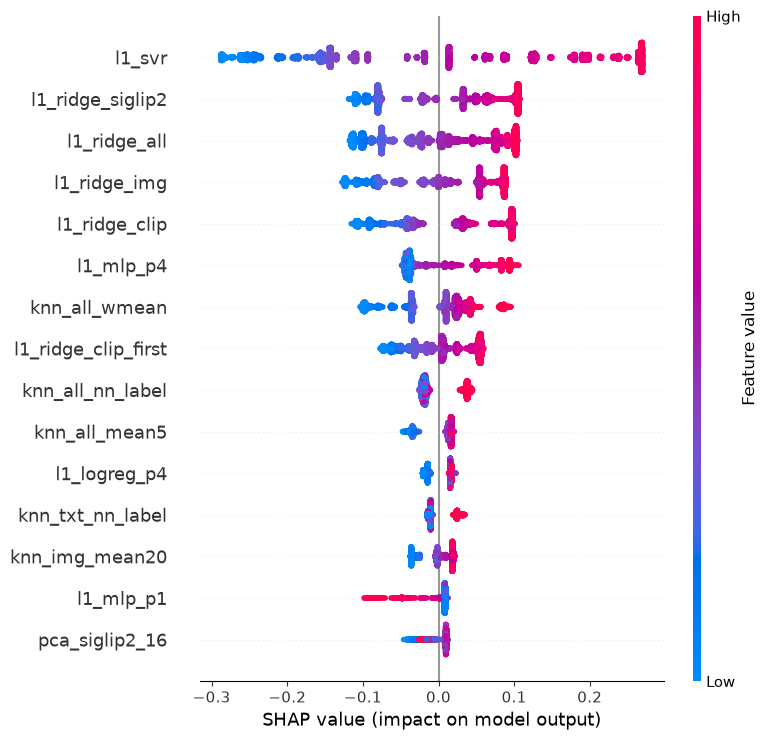

In [34]:
F_train = build_features(tr_idx, tr_idx, L1_train, exclude_self=True)
F_test = build_features(te_idx, tr_idx, L1_test, exclude_self=False)

model = lgb.LGBMRegressor(**LGB_TUNED).fit(F_train, y)
shap_values = shap.TreeExplainer(model).shap_values(F_train)
imp = pd.Series(np.abs(shap_values).mean(0), index=feature_names)


def family(name):
    if name.startswith("knn_img"):
        return "сусіди за фото"
    if name.startswith("knn_txt"):
        return "сусіди за текстом"
    if name.startswith("knn_all"):
        return "сусіди за фото + текстом"
    if name.startswith("dup"):
        return "дублікати опису"
    if name.startswith("l1"):
        return "моделі першого рівня"
    if name.startswith("pca_text"):
        return "PCA тексту"
    if name.startswith("pca"):
        return "PCA фото"
    return "метадані"


fam = (imp.groupby(imp.index.map(family)).sum() / imp.sum()).sort_values(ascending=False)
print("частка |SHAP| за сімействами ознак:")
print(fam.round(3).to_string())
print("\nтоп-12 ознак:")
print((imp / imp.sum()).sort_values(ascending=False).head(12).round(3).to_string())

shap.summary_plot(shap_values, F_train, feature_names=feature_names, max_display=15, show=False)
plt.savefig(FIG_DIR / "models_shap.png", dpi=120, bbox_inches="tight")
plt.show()

In [35]:
# аблація: та сама LGBM multiclass з параметрами Optuna, але без одного сімейства ознак
fam_of = np.array([family(n) for n in feature_names])
ablation = {}
for fam in ["сусіди за фото", "сусіди за текстом", "сусіди за фото + текстом", "моделі першого рівня", "PCA фото", "PCA тексту"]:
    keep = fam_of != fam
    oof = np.zeros(len(tr_idx))
    for (F_tr, y_tr, F_va), (tr, va) in zip(fold_data, folds):
        oof[va] = lgb_multi(F_tr[:, keep], y_tr, F_va[:, keep], LGB_TUNED)
    ablation[fam] = cv_qwk(oof)[0]
full = results["L2 LGBM multiclass (Optuna)"][0]
print(f"повний набір ознак: QWK = {full:.4f}")
print(pd.Series({f"без: {k}": v - full for k, v in ablation.items()}, name="зміна QWK").round(4).to_string())

повний набір ознак: QWK = 0.6157
без: сусіди за фото             -0.0045
без: сусіди за текстом          -0.0023
без: сусіди за фото + текстом   -0.0069
без: моделі першого рівня       -0.0220
без: PCA фото                   -0.0002
без: PCA тексту                 -0.0021


In [36]:
tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-large-patch14")
clip = AutoModel.from_pretrained("openai/clip-vit-large-patch14").eval()
prompts = {
    "кошеня або цуценя": "a photo of a kitten or a puppy",
    "доросла тварина": "a photo of an adult cat or dog",
    "стара тварина": "a photo of an old animal",
    "хвора або поранена тварина": "a photo of a sick or injured animal",
    "тварина в клітці": "a photo of an animal in a cage",
    "тварина на руках у людини": "a photo of a person holding a pet",
    "розмите фото поганої якості": "a blurry low quality photo",
    "породиста тварина": "a photo of a purebred pedigree animal",
    "кілька тварин разом": "a photo of several animals together",
}
with torch.no_grad():
    P = projected(clip.get_text_features(**tokenizer(list(prompts.values()), padding=True, return_tensors="pt")))
P = F.normalize(P, dim=-1).numpy()
sims = emb["pet_clip_mean"][tr_idx] @ P.T
probe = pd.Series({k: spearmanr(sims[:, j], y).correlation for j, k in enumerate(prompts)}, name="кореляція з AdoptionSpeed")
print("плюс означає повільнішу адопцію")
print(probe.sort_values().round(3).to_string())
del clip

плюс означає повільнішу адопцію
кошеня або цуценя             -0.319
тварина на руках у людини     -0.159
породиста тварина             -0.050
стара тварина                 -0.042
розмите фото поганої якості   -0.041
тварина в клітці              -0.025
хвора або поранена тварина    -0.007
доросла тварина                0.009
кілька тварин разом            0.106


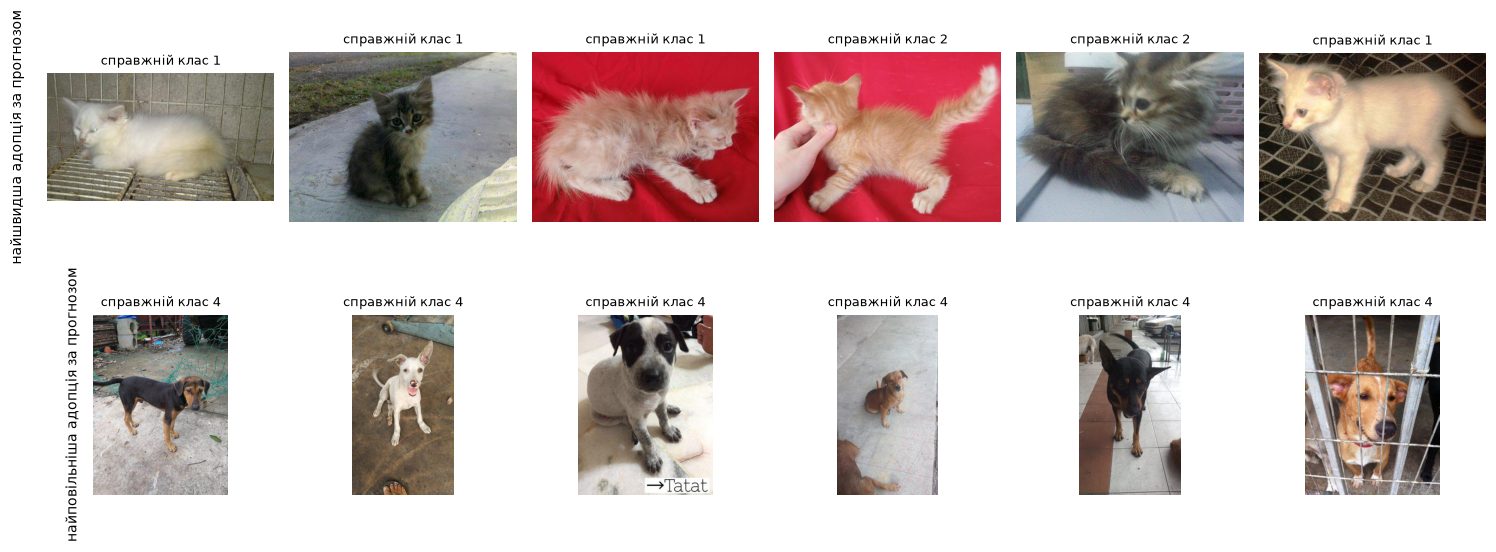

In [37]:
order = np.argsort(blend_oof)
picks = {"найшвидша адопція за прогнозом": order[:6], "найповільніша адопція за прогнозом": order[-6:]}
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for row, (title, idx) in zip(axes, picks.items()):
    for ax, i in zip(row, idx):
        ax.imshow(Image.open(first_photo[pets.PetID.values[tr_idx[i]]]))
        ax.axis("off")
        ax.set_title(f"справжній клас {y[i]}", fontsize=9)
    row[0].text(-0.1, 0.5, title, transform=row[0].transAxes, rotation=90, va="center", ha="right", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "models_extremes.png", dpi=120, bbox_inches="tight")
plt.show()

### Фінальне навчання і сабмішен

Ознаки test: сусіди серед усього train, прогнози першого рівня від моделей, перенавчених на всьому train.
Моделі другого рівня теж перенавчаю на всьому train, бленд рангів, пороги з OOF-бленду. Test не має міток, тому
"усі доступні дані" для навчання з учителем - це весь train, а ембеддинги test уже використані в PCA і як
кандидати в сусіди не використовуються, бо міток у них немає.

пороги на рангах: [0.167 0.421 0.719]


фінальний бленд, recall по класах (OOF):
    справжні  передбачені  recall
1      1197         1120   0.481
2      1773         1706   0.434
3      1328         1745   0.428
4      2133         1860   0.643
   train  submission
1  0.186       0.165
2  0.276       0.254
3  0.206       0.299
4  0.332       0.282
       PetID  AdoptionSpeed
0  6697a7f62              3
1  23b64fe21              2
2  41e824cbe              4
3  6c3d7237b              4
4  97b0b5d92              3
PetID з 8 символів у сабмішені: ['95314294', '35992662', '63521459', '81301773']


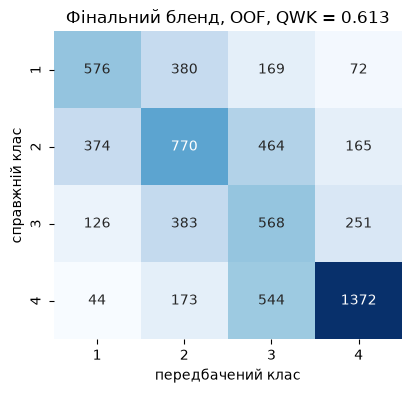

In [38]:
test_preds = {name: fn(F_train, y, F_test) for name, fn in final_fns.items()}
blend_test = rank_blend(list(test_preds.values()))
thr = fit_thresholds(blend_oof, y)
test_class = apply_thresholds(blend_test, thr)
print("пороги на рангах:", thr.round(3))
score_blend, pred_blend = cv_qwk(blend_oof)
print("фінальний бленд, recall по класах (OOF):\n", recall_table(pred_blend).to_string())

sub = pd.DataFrame({"PetID": pets.PetID.values[te_idx], "AdoptionSpeed": test_class})
assert len(sub) == len(te_idx) and sub.PetID.is_unique and set(sub.AdoptionSpeed) <= {1, 2, 3, 4}
sub.to_csv(RES_DIR / "submission.csv", index=False)

dist = pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                     "submission": sub.AdoptionSpeed.value_counts(normalize=True).sort_index()}).round(3)
print(dist.to_string())
print(sub.head())
print("PetID з 8 символів у сабмішені:", sub.PetID[sub.PetID.str.len() == 8].tolist())

pd.DataFrame({"PetID": pets.PetID.values[tr_idx], "AdoptionSpeed": y, "blend_oof": blend_oof, "pred": pred_blend}).to_csv(RES_DIR / "oof_predictions.csv", index=False)
pd.DataFrame({"PetID": sub.PetID, "blend": blend_test, **test_preds}).to_csv(RES_DIR / "test_predictions.csv", index=False)

plt.figure(figsize=(4.5, 4))
sns.heatmap(confusion_matrix(y, pred_blend, labels=CLASSES), annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.xlabel("передбачений клас"); plt.ylabel("справжній клас"); plt.title(f"Фінальний бленд, OOF, QWK = {score_blend:.3f}")
plt.savefig(FIG_DIR / "models_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Додатково: нейромережі end-to-end проти заморожених енкодерів

Сабмішен уже записаний, цей розділ на нього не впливає. Розділи 2 і 3 тримають енкодери замороженими і вчать поверх
векторів лінійні моделі та бустинг. Тут перевіряю альтернативу з програми курсу: навчити з нуля або донавчити моделі
end-to-end, CNN і ResNet-50 на фото, BiLSTM і DistilBERT на тексті. Усе на одному фолді, планка для порівняння це
заморожені CLIP + SigLIP2 + Ridge на тому самому фолді. На Apple M4 Pro розділ іде близько 11 хвилин.

### Дані і фолд

Беру фолд 0 з того самого розбиття, що в розділі 3. Усі моделі вчаться на його train-частині і оцінюються на
val-частині, test тут не потрібен. З фото беру тільки перше, його бачить відвідувач у списку. Генератори випадкових
чисел скидаю, щоб результати розділу не залежали від того, що виконувалося вище.

In [39]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

tr, va = folds[0]                       # позиції в межах tr_idx
y_tr, y_va = y[tr], y[va]
texts_tr = pets.Description.values[tr_idx[tr]]
texts_va = pets.Description.values[tr_idx[va]]
first_photo = photos.drop_duplicates("PetID").set_index("PetID").path   # photos відсортовано за photo_no, перший рядок це фото 1
paths_tr = first_photo[pets.PetID.values[tr_idx[tr]]].tolist()
paths_va = first_photo[pets.PetID.values[tr_idx[va]]].tolist()
print("train:", len(tr), " val:", len(va))
print("класи train:", np.bincount(y_tr)[1:], " val:", np.bincount(y_va)[1:])

train: 5144  val: 1287
класи train: [ 958 1418 1062 1706]  val: [239 355 266 427]


### Оцінка

Кожна модель видає число, класи ріжу порогами. Пороги це квантилі прогнозів на val при накопичених частотах класів
train: розподіл передбачених класів підганяється під train, мітки val у підборі не беруть участі. Простіше за
Nelder-Mead з розділу 3, зате на одному фолді нічого не переоцінює. У таблицю йде QWK останньої епохи, найкращу
епоху за val не вибираю.

In [40]:
def qwk_with_matched_thresholds(score_val, y_train, y_val):
    cum = np.cumsum(np.bincount(y_train, minlength=5)[1:4]) / len(y_train)
    thr = np.quantile(score_val, cum)
    pred = 1 + np.searchsorted(thr, score_val, side="right")
    return cohen_kappa_score(y_val, pred, weights="quadratic")


ft_results = []


def add_result(name, modality, params, epochs, seconds, score_val):
    q = qwk_with_matched_thresholds(score_val, y_tr, y_va)
    ft_results.append(dict(model=name, modality=modality, params=params, epochs=epochs,
                        train_time_s=round(seconds), val_qwk=round(q, 4)))
    print(f"{name}: val QWK = {q:.4f}  ({seconds:.0f} с)")
    return q


def n_params(model):
    return sum(p.numel() for p in model.parameters())

### Спільний цикл навчання

Усі нейромережі регресують номер класу з MSE: QWK карає за квадрат відстані між класами, тому одне число з порогами
природніше за 4 логіти. Батч це кортеж (входи..., ціль), тому один цикл підходить і для фото, і для тексту.

In [41]:
criterion = nn.MSELoss()


def predict(model, loader):
    model.eval()
    out = []
    with torch.no_grad():
        for *inputs, _ in loader:
            out.append(model(*[t.to(device) for t in inputs]).float().cpu())
    return torch.cat(out).numpy()


def fit(model, train_loader, val_loader, optimizer, epochs, scheduler=None):
    history, t0 = [], time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        total, n_seen = torch.zeros((), device=device), 0
        for *inputs, target in train_loader:
            inputs = [t.to(device) for t in inputs]
            target = target.to(device)
            optimizer.zero_grad()
            loss = criterion(model(*inputs), target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total += loss.detach() * len(target)
            n_seen += len(target)
        score_va = predict(model, val_loader)
        q = qwk_with_matched_thresholds(score_va, y_tr, y_va)
        history.append((total.item() / n_seen, q))
        print(f"  епоха {epoch}: train MSE {history[-1][0]:.4f}  val QWK {q:.4f}  ({time.time() - t0:.0f} с)")
    return np.array(history), score_va, time.time() - t0

### Референс: заморожені CLIP + SigLIP2 + Ridge

Та сама пара енкодерів, що в основному пайплайні, і найпростіша модель поверх них. Нейромережі нижче бачать лише перше фото, тому
планка теж на першому фото. Варіант з усіма фото, як у розділі 3, для порівняння.

In [42]:
for kind, label in [("first", "перше фото"), ("mean", "усі фото")]:
    t0 = time.time()
    X = np.hstack([np.load(EMB_DIR / f"pet_clip_{kind}.npy"), np.load(EMB_DIR / f"pet_siglip2_{kind}.npy")]).astype(np.float32)
    ridge = RidgeCV(alphas=np.logspace(-1, 4, 11)).fit(X[tr_idx[tr]], y_tr)
    print(f"{label}: X {X.shape}, alpha = {ridge.alpha_:g}")
    q = add_result(f"CLIP + SigLIP2 заморожені + Ridge, {label}", "фото", ridge.coef_.size, "-", time.time() - t0, ridge.predict(X[tr_idx[va]]))
    if kind == "first":
        qwk_ref = q      # чесна планка: моделі нижче теж бачать лише перше фото

перше фото: X (8322, 1920), alpha = 3.16228
CLIP + SigLIP2 заморожені + Ridge, перше фото: val QWK = 0.5441  (1 с)


усі фото: X (8322, 1920), alpha = 3.16228
CLIP + SigLIP2 заморожені + Ridge, усі фото: val QWK = 0.5795  (1 с)


### Кеш фото

Перше фото кожної тварини фолду декодую один раз: коротша сторона до 256, центральний кроп 256x256, uint8.
Аугментації далі працюють на тензорах, тому епоха не впирається в читання JPEG.

In [43]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
CACHE_SIZE = 256


def load_square(path):
    img = v2.functional.pil_to_tensor(Image.open(path).convert("RGB"))
    return v2.functional.center_crop(v2.functional.resize(img, CACHE_SIZE, antialias=True), CACHE_SIZE)


def build_cache(paths):
    with ThreadPoolExecutor(8) as pool:
        return torch.stack(list(tqdm(pool.map(load_square, paths), total=len(paths), mininterval=10)))


t0 = time.time()
imgs_tr, imgs_va = build_cache(paths_tr), build_cache(paths_va)
print(tuple(imgs_tr.shape), tuple(imgs_va.shape), imgs_tr.dtype, f"{(imgs_tr.nbytes + imgs_va.nbytes) / 2**30:.2f} GB, {time.time() - t0:.0f} с")


class CachedImages(Dataset):
    def __init__(self, imgs, targets, transform):
        self.imgs, self.transform = imgs, transform
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        return self.transform(self.imgs[i]), self.targets[i]


def image_transforms(size):
    to_float = [v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    train_tf = v2.Compose([v2.RandomResizedCrop(size, scale=(0.7, 1.0), antialias=True), v2.RandomHorizontalFlip(), *to_float])
    eval_tf = v2.Compose([v2.Resize(round(size / 0.875), antialias=True), v2.CenterCrop(size), *to_float])   # для 224 це Resize(256) + CenterCrop(224)
    return train_tf, eval_tf


def image_loaders(size, batch_size):
    train_tf, eval_tf = image_transforms(size)
    train_loader = DataLoader(CachedImages(imgs_tr, y_tr, train_tf), batch_size=batch_size, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(CachedImages(imgs_va, y_va, eval_tf), batch_size=2 * batch_size, num_workers=NUM_WORKERS)
    return train_loader, val_loader

(5144, 3, 256, 256) (1287, 3, 256, 256) torch.uint8 1.18 GB, 2 с


### CNN з нуля

Чотири блоки conv3x3 + BatchNorm + ReLU + MaxPool, глобальне усереднення, лінійний вихід. Фото 128x128, 8 епох, Adam.
Це нижня планка: що дає згорткова архітектура без жодного попереднього навчання на 5 тисячах фото.

In [44]:
class SmallCNN(nn.Module):
    def __init__(self, widths=(32, 64, 128, 256)):
        super().__init__()
        blocks, c_in = [], 3
        for c in widths:
            blocks += [nn.Conv2d(c_in, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
            c_in = c
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(c_in, 1), nn.Flatten(0))   # (B, 1) -> (B,)

    def forward(self, x):
        return self.head(self.features(x))


EPOCHS_CNN = 8
train_loader, val_loader = image_loaders(128, batch_size=64)
model = SmallCNN().to(device)
model.head[3].bias.data.fill_(y_tr.mean())   # старт із середнього класу, перші епохи не йдуть на підбір зсуву
x, _ = next(iter(train_loader))
model.eval()
with torch.no_grad():
    print("вхід", tuple(x.shape), "-> вихід", tuple(model(x.to(device)).shape), f" параметрів: {n_params(model):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
hist_cnn, score_cnn, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_CNN)
add_result("CNN з нуля, 128px", "фото", n_params(model), EPOCHS_CNN, sec, score_cnn)
del model
free_memory()

вхід (64, 3, 128, 128) -> вихід (64,)  параметрів: 389,153


  епоха 1: train MSE 1.3572  val QWK 0.0482  (5 с)


  епоха 2: train MSE 1.2690  val QWK 0.1102  (9 с)


  епоха 3: train MSE 1.2633  val QWK 0.1239  (14 с)


  епоха 4: train MSE 1.2519  val QWK 0.1599  (18 с)


  епоха 5: train MSE 1.2430  val QWK 0.1388  (22 с)


  епоха 6: train MSE 1.2280  val QWK 0.1487  (27 с)


  епоха 7: train MSE 1.2290  val QWK 0.1748  (31 с)


  епоха 8: train MSE 1.2298  val QWK 0.1171  (36 с)
CNN з нуля, 128px: val QWK = 0.1171  (36 с)


### ResNet-50: заморожений проти донавченого

Спершу той самий бекбон як заморожений екстрактор: 2048 ознак з передостаннього шару на центральному кропі 224 і Ridge
поверх, так само, як з CLIP у референсі на першому фото. Далі його ж донавчаю повністю, щоб різниця була видна на одному бекбоні.

In [45]:
@torch.no_grad()
def extract_features(model, imgs, transform):
    model.eval()
    loader = DataLoader(CachedImages(imgs, np.zeros(len(imgs)), transform), batch_size=64, num_workers=NUM_WORKERS)
    return torch.cat([model(x.to(device)).float().cpu() for x, _ in loader]).numpy()


t0 = time.time()
_, eval_tf = image_transforms(224)
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
backbone.fc = nn.Identity()
backbone = backbone.to(device)
feats_tr, feats_va = extract_features(backbone, imgs_tr, eval_tf), extract_features(backbone, imgs_va, eval_tf)
print("ознаки:", feats_tr.shape, feats_va.shape, f"({time.time() - t0:.0f} с на витяг)")
ridge = RidgeCV(alphas=np.logspace(-1, 4, 11)).fit(feats_tr, y_tr)
print(f"alpha = {ridge.alpha_:g}")
add_result("ResNet-50 заморожений + Ridge", "фото", ridge.coef_.size, "-", time.time() - t0, ridge.predict(feats_va))
del backbone
free_memory()

ознаки: (5144, 2048) (1287, 2048) (21 с на витяг)


alpha = 316.228
ResNet-50 заморожений + Ridge: val QWK = 0.4479  (22 с)


### ResNet-50 донавчання end-to-end

Голова це один лінійний вихід. Бекбон вчиться з lr 1e-4, голова з 1e-3, AdamW, косинусний спад lr, 4 епохи, батч 32,
аугментації RandomResizedCrop(0.7..1) і горизонтальний фліп. Усі 23.5M параметрів розморожені.

In [46]:
EPOCHS_RN = 4
train_loader, val_loader = image_loaders(224, batch_size=32)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(model.fc.in_features, 1), nn.Flatten(0))
model.fc[1].bias.data.fill_(y_tr.mean())
model = model.to(device)
head_params = list(model.fc.parameters())
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
print(f"параметрів: {n_params(model):,}, з них у голові {sum(p.numel() for p in head_params):,}")

optimizer = torch.optim.AdamW([{"params": backbone_params, "lr": 1e-4}, {"params": head_params, "lr": 1e-3}], weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RN * len(train_loader))
hist_rn, score_rn, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_RN, scheduler)
add_result("ResNet-50 донавчений, 224px", "фото", n_params(model), EPOCHS_RN, sec, score_rn)
del model, optimizer
free_memory()

параметрів: 23,510,081, з них у голові 2,049


  епоха 1: train MSE 1.0212  val QWK 0.4380  (67 с)


  епоха 2: train MSE 0.7451  val QWK 0.4373  (135 с)


  епоха 3: train MSE 0.5360  val QWK 0.4330  (202 с)


  епоха 4: train MSE 0.4281  val QWK 0.4367  (269 с)
ResNet-50 донавчений, 224px: val QWK = 0.4367  (269 с)


### BiLSTM на тексті з нуля

Токенізація регуляркою, словник зі слів train-частини з частотою від 2, ембеддинги 128 вчаться з нуля, один шар
BiLSTM на 128 у кожен бік, mean і max pooling по часу, лінійний вихід. До 200 токенів на опис, 6 епох.

In [47]:
MAX_TOKENS, MIN_FREQ = 200, 2
tokenize = lambda s: re.findall(r"[a-z0-9]+(?:'[a-z]+)?", s.lower())

counter = Counter(tok for s in texts_tr for tok in tokenize(s))
vocab = {"<pad>": 0, "<unk>": 1}
for tok, c in counter.most_common():
    if c < MIN_FREQ:
        break
    vocab[tok] = len(vocab)
print(f"різних слів у train: {len(counter):,}, у словнику: {len(vocab):,}")


class TextDataset(Dataset):
    def __init__(self, texts, targets):
        self.ids = [torch.tensor([vocab.get(t, 1) for t in tokenize(s)][:MAX_TOKENS] or [0]) for s in texts]   # порожній опис = один <pad>
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        return self.ids[i], self.targets[i]


def collate_text(batch):
    ids, targets = zip(*batch)
    lengths = torch.tensor([len(x) for x in ids])
    return pad_sequence(ids, batch_first=True), lengths, torch.stack(targets)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(4 * hidden, 1), nn.Flatten(0))

    def forward(self, ids, lengths):
        packed = pack_padded_sequence(self.emb(ids), lengths.cpu(), batch_first=True, enforce_sorted=False)   # довжини для pack лише на CPU
        out, _ = pad_packed_sequence(self.lstm(packed)[0], batch_first=True)
        mask = (torch.arange(out.shape[1], device=out.device)[None] < lengths[:, None])[..., None]
        mean = (out * mask).sum(1) / mask.sum(1)
        mx = out.masked_fill(~mask, float("-inf")).max(1).values
        return self.head(torch.cat([mean, mx], 1))


EPOCHS_LSTM = 6
train_loader = DataLoader(TextDataset(texts_tr, y_tr), batch_size=64, shuffle=True, collate_fn=collate_text, num_workers=NUM_WORKERS)
val_loader = DataLoader(TextDataset(texts_va, y_va), batch_size=128, collate_fn=collate_text, num_workers=NUM_WORKERS)
model = BiLSTM(len(vocab)).to(device)
model.head[1].bias.data.fill_(y_tr.mean())
ids, lengths, _ = next(iter(train_loader))
print("батч", tuple(ids.shape), "довжини від", lengths.min().item(), "до", lengths.max().item(), f" параметрів: {n_params(model):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
hist_lstm, score_lstm, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_LSTM)
add_result("BiLSTM з нуля", "текст", n_params(model), EPOCHS_LSTM, sec, score_lstm)
del model
free_memory()

різних слів у train: 12,419, у словнику: 7,182


батч (64, 200) довжини від 1 до 200  параметрів: 1,184,001


  епоха 1: train MSE 1.2155  val QWK 0.2331  (21 с)


  епоха 2: train MSE 1.1040  val QWK 0.2722  (42 с)


  епоха 3: train MSE 0.9853  val QWK 0.2909  (65 с)


  епоха 4: train MSE 0.8651  val QWK 0.2964  (84 с)


  епоха 5: train MSE 0.7387  val QWK 0.2915  (104 с)


  епоха 6: train MSE 0.6192  val QWK 0.2803  (126 с)
BiLSTM з нуля: val QWK = 0.2803  (126 с)


### DistilBERT донавчання

`distilbert-base-uncased` з регресійною головою на 1 вихід (її ваги нові, решта з претрену), 128 токенів, батч 32,
lr 3e-5, AdamW з лінійним розігрівом і спадом, 3 епохи. Це 67M параметрів проти 1.2M у BiLSTM, але головне тут не розмір,
а попереднє навчання на тексті.

In [48]:
MODEL_NAME, MAX_LEN = "distilbert-base-uncased", 128
EPOCHS_BERT = 3
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tensor_dataset(texts, targets):
    enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=MAX_LEN, return_tensors="pt")   # фіксована довжина, однакові форми батчів
    return TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(targets, dtype=torch.float32))


class BertRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1, problem_type="regression")

    def forward(self, input_ids, attention_mask):
        return self.bert(input_ids=input_ids, attention_mask=attention_mask).logits[:, 0]


ds_tr, ds_va = tensor_dataset(texts_tr, y_tr), tensor_dataset(texts_va, y_va)
print(f"input_ids {tuple(ds_tr.tensors[0].shape)}, упираються в {MAX_LEN} токенів: {(ds_tr.tensors[1].sum(1) == MAX_LEN).float().mean():.0%} описів train")
train_loader = DataLoader(ds_tr, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(ds_va, batch_size=64, num_workers=NUM_WORKERS)
model = BertRegressor().to(device)
model.bert.classifier.bias.data.fill_(y_tr.mean())
print(f"параметрів: {n_params(model):,}")
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
steps = EPOCHS_BERT * len(train_loader)
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * steps), steps)
hist_bert, score_bert, sec = fit(model, train_loader, val_loader, optimizer, EPOCHS_BERT, scheduler)
add_result("DistilBERT донавчений", "текст", n_params(model), EPOCHS_BERT, sec, score_bert)
del model, optimizer
free_memory()

input_ids (5144, 128), упираються в 128 токенів: 21% описів train


параметрів: 66,954,241


  епоха 1: train MSE 1.2135  val QWK 0.2164  (68 с)


  епоха 2: train MSE 1.0328  val QWK 0.2772  (135 с)


  епоха 3: train MSE 0.8124  val QWK 0.3020  (203 с)
DistilBERT донавчений: val QWK = 0.3020  (203 с)


### Порівняння

Усі моделі на одному фолді з однаковою процедурою порогів. `params` це кількість параметрів, що навчалися: для Ridge
це коефіцієнти поверх замороженого енкодера.

                                           model modality    params epochs  train_time_s  val_qwk
0    CLIP + SigLIP2 заморожені + Ridge, усі фото     фото      1920      -             1   0.5795
1  CLIP + SigLIP2 заморожені + Ridge, перше фото     фото      1920      -             1   0.5441
2                  ResNet-50 заморожений + Ridge     фото      2048      -            22   0.4479
3                    ResNet-50 донавчений, 224px     фото  23510081      4           269   0.4367
4                          DistilBERT донавчений    текст  66954241      3           203   0.3020
5                                  BiLSTM з нуля    текст   1184001      6           126   0.2803
6                              CNN з нуля, 128px     фото    389153      8            36   0.1171


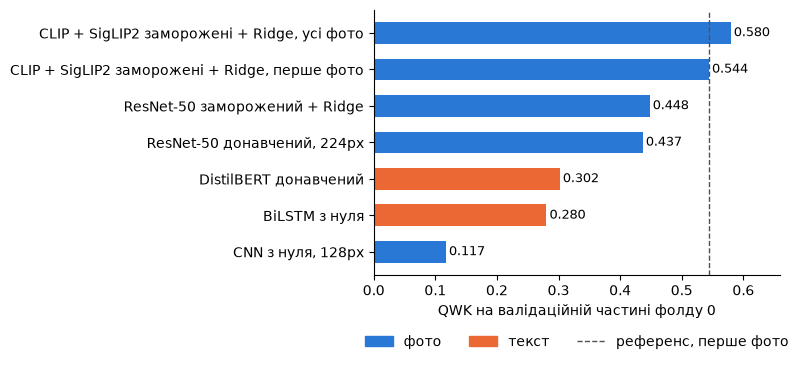

In [49]:
table = pd.DataFrame(ft_results).sort_values("val_qwk", ascending=False).reset_index(drop=True)
table.to_csv(RES_DIR / "finetune_results.csv", index=False)
print(table.to_string())

COLORS = {"фото": "#2a78d6", "текст": "#eb6834"}
t = table.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(t.model, t.val_qwk, color=[COLORS[m] for m in t.modality], height=0.6)
for b, v in zip(bars, t.val_qwk):
    ax.text(max(v, 0) + 0.005, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center", fontsize=9)
ref_line = ax.axvline(qwk_ref, color="#52514e", ls="--", lw=1)
ax.set_xlim(min(0, t.val_qwk.min() - 0.03), max(0.5, t.val_qwk.max() + 0.08))
ax.set_xlabel("QWK на валідаційній частині фолду 0")
ax.spines[["top", "right"]].set_visible(False)
ax.legend([*(plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()), ref_line], [*COLORS.keys(), "референс, перше фото"], frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.tight_layout()
plt.savefig(FIG_DIR / "finetune_summary.png", dpi=120, bbox_inches="tight")
plt.show()

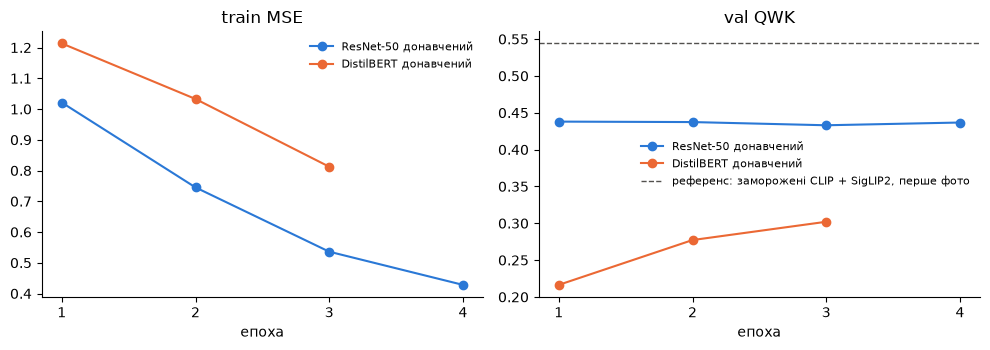

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for name, hist, color in [("ResNet-50 донавчений", hist_rn, COLORS["фото"]), ("DistilBERT донавчений", hist_bert, COLORS["текст"])]:
    ep = np.arange(1, len(hist) + 1)
    axes[0].plot(ep, hist[:, 0], "o-", color=color, label=name)
    axes[1].plot(ep, hist[:, 1], "o-", color=color, label=name)
axes[1].axhline(qwk_ref, color="#52514e", ls="--", lw=1, label="референс: заморожені CLIP + SigLIP2, перше фото")
axes[0].set_title("train MSE")
axes[1].set_title("val QWK")
for ax in axes:
    ax.set_xlabel("епоха")
    ax.set_xticks(np.arange(1, max(len(hist_rn), len(hist_bert)) + 1))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "finetune_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### Висновки розділу

Попереднє навчання вирішує все. CNN з нуля на 5 тисячах фото дає QWK 0.12, ResNet-50 з вагами ImageNet як
заморожений екстрактор 0.45, заморожені CLIP + SigLIP2 з Ridge на тому самому першому фото 0.54 (на всіх фото
0.58). Донавчання ResNet-50 end-to-end за 4 епохи не додає нічого (0.44 проти 0.45 замороженого): train MSE
падає з 1.02 до 0.43, а val QWK стоїть на місці, тобто мережа запам'ятовує 5 тисяч фото замість того, щоб узагальнювати.

На тексті BiLSTM з нуля дає 0.28, донавчений DistilBERT 0.30. Обидві моделі кращі за CNN з нуля, але слабші за будь-яку
попередньо навчену модель на фото і не кращі за заморожені текстові ембеддинги з Ridge з розділу 3 (0.30-0.34).

Висновок для пайплайну: заморожені контрастивні енкодери, навчені на сотнях мільйонів пар фото-текст, і проста модель
поверх них виграють у донавчання на малому датасеті з великим відривом. Це підтверджує вибір розділу 3: енкодери
заморожені, а зусилля пішли в ознаки сусідів і стекінг.

## 5. Підсумок

Фінальна модель - бленд рангів трьох моделей другого рівня (multiclass і порядковий LightGBM з параметрами Optuna та
CatBoost multiclass) поверх ознак сусідів, прогнозів першого рівня і PCA ембеддингів. QWK на 5-фолдовій
крос-валідації 0.613, розкид по фолдах 0.015. Найкраща одиночна модель, LightGBM multiclass з Optuna, дає 0.616,
різниця в межах розкиду, тому беру бленд як стійкіший до вибору однієї моделі. Сабмішен лежить у
Results/submission.csv, на Kaggle він отримав QWK 0.8023. Це помітно вище за крос-валідацію, хоча за розділом 1
розподіли train і test схожі. Причину розриву окремо не досліджував.

Що дало результат. Ембеддинги фото: Ridge на CLIP 0.587, на SigLIP2 0.592, разом 0.591, тобто другий енкодер сам
по собі не додає, зате всі фото тварини замість одного першого дають +0.025 (0.587 проти 0.562). Текст окремо
слабкий (0.30-0.34) і додає до фото +0.005. SVR на всіх ембеддингах, найкраща модель першого рівня, дає 0.609.
Стекінг з ознаками сусідів піднімає до 0.613-0.616, це теж у межах розкиду по фолдах, але аблація показує, що кожна
частина щось додає: без прогнозів першого рівня LightGBM втрачає 0.022, без кожного сімейства ознак сусідів
0.002-0.007, без PCA тексту 0.002, без PCA фото нічого. Optuna додав +0.005 до регресійного LightGBM, теж на рівні
розкиду, тож тюнінг тут радше демонстрація процедури.

Регуляризація у функції втрат: MLP першого рівня вчиться на cross-entropy з L2-штрафом на ваги і label smoothing і
дає 0.576, слабше за SVR, але його ймовірність класу 4 серед найважливіших ознак другого рівня.

Дисбаланс: ваги класів QWK не покращують (0.607 проти 0.613 без ваг). Пороги замість округлення повертають recall
крайнім класам (клас 1 з 0.14 до 0.44, клас 4 з 0.44 до 0.65), клас 3 при цьому падає з 0.53 до 0.36. За SHAP
регресійного LightGBM 57 % внеску йде від моделей першого рівня, 17 % від PCA фото, 19 % від ознак сусідів. PCA фото
важить у SHAP, але аблація без нього нічого не втрачає: та сама інформація є в прогнозах першого рівня. Zero-shot
зондування CLIP: чим більше фото схоже на кошеня чи цуценя, тим швидша адопція (кореляція -0.32), кілька тварин на
одному фото адоптуються повільніше (+0.11).

Нейромережі end-to-end (розділ 4, фолд 0, перше фото) програють замороженим енкодерам. На фото: CNN з нуля 0.12,
ResNet-50 заморожений 0.45, донавчений 0.44, заморожені CLIP + SigLIP2 з Ridge 0.54. На тексті: BiLSTM з нуля
0.28, донавчений DistilBERT 0.30, не кращі за заморожені текстові ембеддинги з Ridge з розділу 3.

Що ще можна спробувати: SigLIP2 у більшій роздільній здатності (384), окремі моделі для котів і собак, кілька сідів
розбиття з усередненням, ознаки сусідів на рівні окремих фото. І окремо розібратися, чому test оцінюється настільки
вище за крос-валідацію.